# Computational benchmark results

The primary computational endpoint is observed fitting wall time until the protocol stopped an attempt: initialization plus optimization and fitting finalization, excluding held-out evaluation and serialization. Every finite timed attempt is retained, including attempts that reached an iteration or wall-time limit. Convergence counts and outcome markers keep those measurements distinct from completed fits.

Independent parameter orientations are used across fit_repeat by default, but the seed is paired by repeat index across comparable cells. Total identifiable parameter-departure norm is fixed at 10⁻² with fixed factor spectra (and wrapped-normal residual variance 5), so seeds change orientation rather than strength or conditioning. This common-random-numbers design separates seed-orientation sensitivity from arbitrary cell ordering. Medians and interquartile ranges (IQRs) summarize repeat-to-repeat timing variability. Conditional time to convergence remains available as a secondary diagnostic, but it is not substituted for the all-attempt computational-effort endpoint. QC plots precede the compact publication tables.

In [24]:
from __future__ import annotations

import json
import math
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import HTML, display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9.5,
    'axes.titlesize': 10.5,
    'axes.labelsize': 9.5,
    'legend.fontsize': 8,
    'figure.dpi': 120,
})

MODEL_INFO = {
    'wrapped_normal': ('Wrapped normal', 'Torus', 0),
    'vmf': ('von Mises--Fisher', 'Sphere', 1),
    'fisher_bingham': ('Fisher--Bingham', 'Sphere', 2),
    'acg': ('ACG', 'Projective', 3),
    'watson': ('Watson', 'Projective', 4),
    'bingham': ('Bingham', 'Projective', 5),
    'matrix_fisher': ('Matrix Fisher', 'Stiefel', 6),
    'matrix_fisher_bingham': ('Matrix Fisher--Bingham', 'Stiefel', 7),
    'macg': ('MACG', 'Grassmann', 8),
    'matrix_bingham': ('Matrix Bingham', 'Grassmann', 9),
}
MODEL_ORDER = list(MODEL_INFO)
MANIFOLD_ORDER = ['Torus', 'Sphere', 'Projective', 'Stiefel', 'Grassmann']
RANK_ORDER = ['rank1', 'half', 'full']
RANK_NAMES = {'rank1': 'rank 1', 'half': 'half rank', 'full': 'full rank'}
RANK_MARKERS = {'rank1': 'o', 'half': 's', 'full': '^'}
CONCENTRATION_ORDER = ['low', 'high']
MODEL_COLORS = dict(zip(MODEL_ORDER, plt.get_cmap('tab10').colors))

NORMALIZER_NAMES = {
    'finite_winding_lattice_radius_1': 'Winding lattice (r=1)',
    'finite_winding_lattice_radius_0': 'Central winding only',
    'intractable_winding_lattice_skipped': 'Winding lattice (protocol limit)',
    'continuous_euler_quadrature': 'Euler quadrature',
    'kummer_series': 'Kummer series',
    'closed_form': 'Closed form',
    'first_order_saddlepoint_relative_to_normalized_haar': '1st-order saddlepoint (Haar)',
    'second_order_saddlepoint_relative_to_normalized_haar': '2nd-order saddlepoint (Haar)',
    'exact_gauss_jacobi_bessel_relative_to_normalized_haar': (
        'Exact Gauss–Jacobi/Bessel\n(normalized Haar)'
    ),
    'closed_form_relative_to_normalized_haar': 'Closed form (Haar)',
}
ITERATION_LIMIT_REASONS = {'max_iter', 'max_iterations', 'iteration_limit'}
TIME_LIMIT_REASONS = {
    'max_optimization_seconds', 'max_fit_seconds', 'max_attempt_seconds',
    'time_limit', 'timeout', 'soft_time_limit',
}

def expected_normalizer(distribution: str, settings: dict) -> str:
    if distribution == 'wrapped_normal':
        radius = int(settings.get('wrapped_winding_radius', 1))
        return f'Winding lattice (r={radius})' if radius else 'Central winding only'
    if distribution == 'watson':
        return 'Kummer series'
    if distribution in {'vmf', 'bingham', 'fisher_bingham'}:
        return 'Euler quadrature'
    if distribution == 'acg':
        return 'Closed form'
    if distribution in {'matrix_fisher', 'matrix_bingham', 'matrix_fisher_bingham'}:
        order = int(settings.get('saddlepoint_order', 1))
        suffix = 'st' if order == 1 else 'nd' if order == 2 else 'th'
        return f'{order}{suffix}-order saddlepoint (Haar)'
    if distribution == 'macg':
        return 'Closed form (Haar)'
    return 'Unspecified'


## Load and validate the benchmark

The loader prefers a schema-v3 result directory when present, then falls back to schema v2 and legacy names. The manifest supplies the planned cells; the repeat-level file supplies observed outcomes.

In [25]:
def locate_upwards(relative_paths: list[Path]) -> Path:
    roots = [Path.cwd(), *Path.cwd().parents]
    for root in roots:
        for relative in relative_paths:
            candidate = (root / relative).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'Could not locate any of: {relative_paths}')

# Prefer schema v3, but retain explicit fallbacks for the current schema-v2 run and legacy files.
results_path = locate_upwards([
    Path('computational_results_schema_v4/results.csv'),
    Path('computational_results_v4/results.csv'),
    Path('overview_paper/computational_results_schema_v4/results.csv'),
    Path('overview_paper/computational_results_v4/results.csv'),
    Path('computational_results_schema_v3/results.csv'),
    Path('computational_results_v3/results.csv'),
    Path('overview_paper/computational_results_schema_v3/results.csv'),
    Path('overview_paper/computational_results_v3/results.csv'),
    Path('computational_results_schema_v2/results.csv'),
    Path('computational_results_v2/results.csv'),
    Path('overview_paper/computational_results_schema_v2/results.csv'),
    Path('overview_paper/computational_results_v2/results.csv'),
    Path('computational_results/results.csv'),
    Path('overview_paper/computational_results/results.csv'),
])
config_path = results_path.with_name('experiment_config.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}
settings = config.get('settings', config)
environment = config.get('environment', settings.get('runtime_identity', {}))
raw = pd.read_csv(results_path)

def coalesce_column(target: str, candidates: list[str], default=np.nan) -> None:
    if target in raw:
        values = raw[target].copy()
    else:
        values = pd.Series(default, index=raw.index)
    for candidate in candidates:
        if candidate not in raw:
            continue
        missing = values.isna() | values.astype(str).str.strip().eq('')
        values = values.where(~missing, raw[candidate])
    raw[target] = values

# Schema-v3 names come first; schema-v2 names remain accepted.
coalesce_column('status', ['attempt_status', 'result_status'], '')
coalesce_column('stopping_reason', ['stop_reason', 'termination_reason'], '')
coalesce_column('fit_outcome', ['outcome', 'optimization_outcome'], '')
coalesce_column(
    'observed_fit_seconds',
    [
        'observed_total_fit_seconds', 'total_fit_seconds',
        'fit_seconds', 'attempt_seconds',
    ],
)
# Keep the old total-time name populated for timing-accounting diagnostics.
coalesce_column(
    'total_fit_seconds',
    ['observed_fit_seconds', 'fit_seconds', 'attempt_seconds'],
)
coalesce_column('initialization_seconds', ['initialization_wall_seconds'], 0.0)
coalesce_column(
    'median_seconds_per_iteration',
    ['median_seconds_per_update', 'median_update_seconds', 'seconds_per_iteration'],
)
coalesce_column('iterations', ['optimizer_updates', 'update_iterations'])
coalesce_column('heldout_log_score_gain_per_dof', ['heldout_gain_per_dof'])
coalesce_column('n_train', ['training_observations'])
coalesce_column('normalizer_kind', ['normalizer_method'], '')
coalesce_column(
    'normalizer_benchmark_kind',
    ['normalizer_value_gradient_kind'],
    '',
)
coalesce_column(
    'fixed_objective_value_gradient_wall_median_seconds',
    [],
)
coalesce_column(
    'normalizer_value_gradient_wall_median_seconds',
    [],
)
coalesce_column('error_message', ['message'], '')
coalesce_column('error_type', ['exception_type'], '')
coalesce_column('converged', ['convergence_reached'])
coalesce_column(
    'initial_train_log_score_gain_over_uniform',
    ['initial_train_gain_over_uniform'],
)
coalesce_column(
    'initial_mean_train_log_likelihood',
    ['initial_train_mean_log_likelihood'],
)

required_columns = {
    'distribution', 'ambient_dim', 'matrix_cols', 'rank_label',
    'concentration_label', 'source_filename', 'fit_repeat', 'status',
}
missing_required = required_columns.difference(raw.columns)
if missing_required:
    raise ValueError(f'Results file is missing required columns: {sorted(missing_required)}')

if raw['heldout_log_score_gain_per_dof'].isna().all():
    if {'heldout_log_score_gain', 'intrinsic_support_dimension'}.issubset(raw.columns):
        numerator = pd.to_numeric(raw['heldout_log_score_gain'], errors='coerce')
        denominator = pd.to_numeric(raw['intrinsic_support_dimension'], errors='coerce')
        raw['heldout_log_score_gain_per_dof'] = numerator / denominator
if 'median_seconds_per_iteration_per_training_observation' not in raw:
    raw['median_seconds_per_iteration_per_training_observation'] = (
        pd.to_numeric(raw['median_seconds_per_iteration'], errors='coerce')
        / pd.to_numeric(raw['n_train'], errors='coerce')
    )

numeric_columns = [
    'fit_repeat', 'ambient_dim', 'matrix_cols', 'active_rank', 'n_samples',
    'n_train', 'n_test', 'observed_fit_seconds',
    'total_fit_seconds', 'fit_seconds',
    'initialization_seconds', 'optimizer_overhead_seconds',
    'median_seconds_per_iteration',
    'median_seconds_per_iteration_per_training_observation',
    'iterations', 'heldout_log_score_gain_per_dof', 'parameter_count',
    'mean_heldout_log_likelihood_saddlepoint_order2',
    'order2_minus_order1_heldout_log_likelihood',
    'second_order_validation_seconds', 'attempt_seconds',
    'fixed_objective_value_gradient_wall_median_seconds',
    'normalizer_value_gradient_wall_median_seconds',
    'initial_train_log_score_gain_over_uniform',
    'initial_mean_train_log_likelihood',
]
for column in numeric_columns:
    if column in raw:
        raw[column] = pd.to_numeric(raw[column], errors='coerce')

def parse_optional_bool(value):
    if pd.isna(value) or value == '':
        return pd.NA
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    text = str(value).strip().lower()
    if text in {'1', 'true', 'yes', 'converged'}:
        return True
    if text in {'0', 'false', 'no', 'not_converged'}:
        return False
    return pd.NA

status_text = raw['status'].fillna('').astype(str).str.strip().str.lower()
stop_text = raw['stopping_reason'].fillna('').astype(str).str.strip().str.lower()
outcome_text = raw['fit_outcome'].fillna('').astype(str).str.strip().str.lower()

raw['iteration_limit_flag'] = (
    stop_text.isin(ITERATION_LIMIT_REASONS)
    | stop_text.str.contains(r'max.?iter|iteration.?limit', regex=True)
    | outcome_text.str.contains(r'max.?iter|iteration.?limit', regex=True)
)
raw['time_limit_flag'] = (
    stop_text.isin(TIME_LIMIT_REASONS)
    | stop_text.str.contains(r'time.?limit|timeout|max.*seconds', regex=True)
    | outcome_text.str.contains(r'time.?limit|timeout|max.*seconds', regex=True)
    | status_text.isin({'time_limit', 'censored'})
)
raw['error_flag'] = (
    status_text.isin({'error', 'failed', 'failure'})
    | outcome_text.str.contains(r'error|fail', regex=True)
)
raw['skipped_flag'] = status_text.isin({'skipped', 'not_applicable'})
raw['pending_flag'] = status_text.isin({'pending', 'queued', 'running'})

explicit_convergence = pd.Series(
    raw['converged'].map(parse_optional_bool),
    index=raw.index,
    dtype='boolean',
)
inferred_convergence = (
    status_text.isin({'ok', 'complete', 'success'})
    & ~raw['iteration_limit_flag']
    & ~raw['time_limit_flag']
    & ~raw['error_flag']
)
raw['converged_flag'] = explicit_convergence.fillna(inferred_convergence).astype(bool)
raw['timed_flag'] = (
    np.isfinite(raw['observed_fit_seconds'])
    & raw['observed_fit_seconds'].gt(0)
    & ~raw['skipped_flag']
    & ~raw['pending_flag']
)
raw['resolved_flag'] = (
    ~raw['pending_flag']
    & (
        raw['timed_flag'] | raw['skipped_flag'] | raw['error_flag']
        | raw['iteration_limit_flag'] | raw['time_limit_flag']
        | status_text.ne('')
    )
)

# Retries may append a replacement record for the same repeat.
latest = raw.drop_duplicates(['source_filename', 'fit_repeat'], keep='last').copy()
requested_repeats = int(config.get('fit_repeats', settings.get('fit_repeats', 0)) or 0)
if requested_repeats <= 0:
    requested_repeats = int(latest['fit_repeat'].max()) + 1 if len(latest) else 1
latest = latest.loc[latest['fit_repeat'].isin(range(requested_repeats))].copy()

def configured_values(key: str):
    value = settings.get(key, config.get(key, []))
    if value in (None, ''):
        return []
    if isinstance(value, str):
        return [part.strip() for part in value.split(',') if part.strip()]
    return list(value)

configured_manifest = settings.get('manifest', config.get('manifest'))
manifest_candidates = []
if configured_manifest:
    manifest_candidates.append(Path(configured_manifest))
manifest_candidates.extend([
    results_path.parent.parent / 'directional_samples_protocol_v4/manifest.csv',
    results_path.parent.parent / 'directional_samples_v4/manifest.csv',
    results_path.parent.parent / 'directional_samples_protocol_v3/manifest.csv',
    results_path.parent.parent / 'directional_samples_v3/manifest.csv',
    results_path.parent.parent / 'directional_samples_protocol_v2/manifest.csv',
    results_path.parent.parent / 'directional_samples_v2/manifest.csv',
    Path('overview_paper/directional_samples_protocol_v4/manifest.csv'),
    Path('overview_paper/directional_samples_v4/manifest.csv'),
    Path('overview_paper/directional_samples_protocol_v3/manifest.csv'),
    Path('overview_paper/directional_samples_v3/manifest.csv'),
    Path('overview_paper/directional_samples_protocol_v2/manifest.csv'),
    Path('overview_paper/directional_samples_v2/manifest.csv'),
    results_path.parent.parent / 'directional_samples/manifest.csv',
    Path('overview_paper/directional_samples/manifest.csv'),
])
manifest_path = next((path.resolve() for path in manifest_candidates if path.exists()), None)
if manifest_path is not None:
    manifest = pd.read_csv(manifest_path).rename(columns={'filename': 'source_filename'})
    filters = {
        'distribution': configured_values('distributions'),
        'ambient_dim': [int(value) for value in configured_values('dimensions')],
        'rank_label': configured_values('ranks'),
        'concentration_label': configured_values('concentrations'),
    }
    for column, values in filters.items():
        if values:
            manifest = manifest.loc[manifest[column].isin(values)]
    planned = manifest.drop_duplicates('source_filename', keep='last').copy()
else:
    manifest = pd.DataFrame()
    planned = latest.drop_duplicates('source_filename', keep='last').copy()

# Never discard an observed cell because an older config points at a different manifest path.
observed_cells = latest.drop_duplicates('source_filename', keep='last')
planned = (
    pd.concat([planned, observed_cells], ignore_index=True, sort=False)
    .drop_duplicates('source_filename', keep='first')
)

expected_attempts = len(planned) * requested_repeats
resolved_attempts = int(latest['resolved_flag'].sum())
unresolved_attempts = max(expected_attempts - resolved_attempts, 0)
benchmark_is_draft = unresolved_attempts > 0


### Run identity, comparability, and progress

In [26]:
def nonempty_unique(series: pd.Series) -> list:
    values = series.dropna()
    values = values.loc[values.astype(str).str.strip().ne('')]
    return values.drop_duplicates().tolist()

run_ids = nonempty_unique(raw['run_id']) if 'run_id' in raw else []
config_run_id = config.get('run_id', '')
if len(run_ids) > 1:
    warnings.warn(f'Mixed run_id values found: {run_ids}', RuntimeWarning)
if config_run_id and run_ids and config_run_id not in run_ids:
    warnings.warn('Configuration run_id does not match results.csv.', RuntimeWarning)
if not config_run_id and not run_ids:
    warnings.warn('Run identity is unavailable for this legacy result file.', RuntimeWarning)

invariant_columns = [
    'result_schema_version', 'dtype', 'device', 'learning_rate', 'threads',
    'max_iterations', 'max_fit_seconds', 'max_attempt_seconds', 'tolerance',
    'initialization_tolerance', 'convergence_window', 'optimizer_restarts',
    'initialization', 'convergence_normalization', 'timing_warmup_iterations',
    'saddlepoint_order', 'saddlepoint_iterations', 'saddlepoint_tolerance',
    'integration_points', 'wrapped_winding_radius', 'git_revision',
    'hostname', 'cpu_model', 'python_version', 'numpy_version', 'scipy_version',
    'torch_version', 'omp_num_threads', 'mkl_num_threads', 'openblas_num_threads',
    'numexpr_num_threads',
]
mixed_settings = {
    column: nonempty_unique(raw[column])
    for column in invariant_columns
    if column in raw and len(nonempty_unique(raw[column])) > 1
}
if mixed_settings:
    warnings.warn(f'Mixed benchmark settings detected: {mixed_settings}', RuntimeWarning)

accounting_residual = np.nan
if 'timing_accounting_residual_seconds' in raw:
    absolute_residual = pd.to_numeric(
        raw['timing_accounting_residual_seconds'], errors='coerce'
    ).abs()
    relative_residual = absolute_residual / raw['total_fit_seconds']
elif {
    'total_fit_seconds', 'fit_seconds', 'initialization_seconds',
    'optimizer_overhead_seconds',
}.issubset(raw.columns):
    accounted = (
        raw['fit_seconds'] + raw['initialization_seconds']
        + raw['optimizer_overhead_seconds']
    )
    for component in ('post_update_evaluation_seconds', 'finalization_seconds'):
        if component in raw:
            accounted = accounted + pd.to_numeric(
                raw[component], errors='coerce'
            ).fillna(0.0)
    relative_residual = (
        raw['total_fit_seconds'] - accounted
    ).abs() / raw['total_fit_seconds']
else:
    relative_residual = pd.Series(dtype=float)
if not relative_residual.empty:
    accounting_residual = relative_residual.replace(
        [np.inf, -np.inf], np.nan
    ).max()
    if pd.notna(accounting_residual) and accounting_residual > 0.03:
        warnings.warn(
            f'Maximum timing-accounting residual is {accounting_residual:.1%}.',
            RuntimeWarning,
        )

schema_version = config.get(
    'result_schema_version',
    settings.get(
        'result_schema_version',
        nonempty_unique(raw['result_schema_version'])[0]
        if 'result_schema_version' in raw and nonempty_unique(raw['result_schema_version'])
        else 'legacy',
    ),
)
seed_scheme_values = (
    nonempty_unique(raw['initialization_seed_scheme'])
    if 'initialization_seed_scheme' in raw else []
)
seed_scheme = (
    seed_scheme_values[0] if len(seed_scheme_values) == 1
    else 'mixed' if seed_scheme_values else 'legacy / unavailable'
)
metadata_rows = [
    ('Results', str(results_path)),
    ('Modified', datetime.fromtimestamp(
        results_path.stat().st_mtime
    ).astimezone().isoformat(timespec='seconds')),
    ('Rows (raw / latest)', f'{len(raw)} / {len(latest)}'),
    ('Schema / run ID', f'{schema_version} / {config_run_id or (run_ids[0] if len(run_ids) == 1 else "unavailable")}'),
    ('Planned cells / repeats', f'{len(planned)} / {requested_repeats}'),
    ('Repeat initialization', settings.get(
        'repeat_initialization', 'legacy / unavailable'
    )),
    ('Seed pairing / norm / wrapped variance', (
        f"{seed_scheme} / "
        f"{settings.get('isotropic_natural_scale', 'unknown')} / "
        f"{settings.get('isotropic_wrapped_variance', 'unknown')}"
    )),
    ('Resolved / expected attempts', f'{resolved_attempts} / {expected_attempts}'),
    ('Device / dtype / threads', (
        f"{settings.get('resolved_device', settings.get('device', 'unknown'))} / "
        f"{settings.get('dtype', 'unknown')} / {settings.get('threads', 'unknown')}"
    )),
    ('Host / CPU', (
        f"{environment.get('hostname', 'unavailable')} / "
        f"{environment.get('cpu_model', 'unavailable')}"
    )),
    ('Tolerance / plateau window', (
        f"{settings.get('tolerance', 'unknown')} / "
        f"{settings.get('convergence_window', 'unknown')}"
    )),
    ('Iteration / fit-time cap', (
        f"{settings.get('max_iterations', 'unknown')} / "
        f"{settings.get('max_fit_seconds', 'none')} s"
    )),
    ('Max timing-accounting residual', (
        f'{accounting_residual:.2%}' if pd.notna(accounting_residual)
        else 'unavailable'
    )),
]
display(
    pd.DataFrame(metadata_rows, columns=['Item', 'Value'])
    .style.hide(axis='index')
    .set_caption('Benchmark run metadata')
)
if benchmark_is_draft:
    display(HTML(
        '<div style="border:2px solid #b45309;background:#fff7ed;color:#7c2d12;'
        'padding:0.7em 0.9em;margin:0.7em 0;font-family:sans-serif">'
        f'<strong>DRAFT — benchmark still incomplete.</strong> '
        f'{unresolved_attempts} of {expected_attempts} planned attempts are unresolved. '
        'Finite results below are retained; pending work is not silently dropped.'
        '</div>'
    ))


/tmp/ipykernel_2018890/3274671822.py:32: RuntimeWarning: Mixed benchmark settings detected: {'saddlepoint_order': ['not_applicable', '2']}
  warnings.warn(f'Mixed benchmark settings detected: {mixed_settings}', RuntimeWarning)


Item,Value
Results,/dtu-compute/HCP_dFC/2023/hcp_dfc/overview_paper/computational_results_schema_v4/results.csv
Modified,2026-09-02T02:54:23+02:00
Rows (raw / latest),500 / 500
Schema / run ID,4 / 3dd392e33da66f38
Planned cells / repeats,100 / 5
Repeat initialization,independent
Seed pairing / norm / wrapped variance,paired_by_fit_repeat / 0.01 / 5.0
Resolved / expected attempts,500 / 500
Device / dtype / threads,cpu / float64 / 1
Host / CPU,n-62-21-99 / Intel(R) Xeon(R) CPU E5-2650 v4 @ 2.20GHz


## Cell summaries and outcome coverage

Primary timing, initialization, per-update cost, and update-count summaries use all finite timed attempts. Outcome counts are carried alongside the summaries; one limit-stopped repeat never erases the other observations.

In [27]:
SUMMARY_METRICS = [
    'observed_fit_seconds',
    'initialization_seconds',
    'median_seconds_per_iteration',
    'median_seconds_per_iteration_per_training_observation',
    'iterations',
    'heldout_log_score_gain_per_dof',
    'fixed_objective_value_gradient_wall_median_seconds',
    'normalizer_value_gradient_wall_median_seconds',
]

def summarize_values(values: pd.Series, prefix: str) -> dict:
    numeric = pd.to_numeric(values, errors='coerce').replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if numeric.empty:
        return {
            f'{prefix}_mean': np.nan,
            f'{prefix}_q1': np.nan,
            f'{prefix}_median': np.nan,
            f'{prefix}_q3': np.nan,
            f'{prefix}_n': 0,
        }
    q1, median, q3 = numeric.quantile([0.25, 0.5, 0.75])
    return {
        f'{prefix}_mean': float(numeric.mean()),
        f'{prefix}_q1': float(q1),
        f'{prefix}_median': float(median),
        f'{prefix}_q3': float(q3),
        f'{prefix}_n': int(len(numeric)),
    }

groups = {
    name: group
    for name, group in latest.groupby('source_filename', sort=False)
}
cell_records = []
for _, planned_row in planned.iterrows():
    filename = planned_row['source_filename']
    group = groups.get(filename, latest.iloc[0:0])
    timed_group = group.loc[group['timed_flag']]
    converged_group = timed_group.loc[timed_group['converged_flag']]
    iteration_group = group.loc[group['iteration_limit_flag']]
    time_group = group.loc[group['time_limit_flag']]
    error_group = group.loc[group['error_flag']]
    skipped_group = group.loc[group['skipped_flag']]

    distribution = planned_row.get(
        'distribution',
        group['distribution'].iloc[-1] if len(group) else 'unknown',
    )
    p = pd.to_numeric(planned_row.get('ambient_dim', np.nan), errors='coerce')
    q = pd.to_numeric(planned_row.get('matrix_cols', 0), errors='coerce')
    rank_label = planned_row.get(
        'rank_label',
        group['rank_label'].iloc[-1] if len(group) else 'unknown',
    )
    concentration = planned_row.get(
        'concentration_label',
        group['concentration_label'].iloc[-1] if len(group) else 'unknown',
    )
    model_name, manifold, model_order = MODEL_INFO.get(
        distribution, (distribution, 'Other', 999)
    )
    q_int = int(q) if pd.notna(q) else 0
    table_model = f'{model_name} (q={q_int})' if q_int else model_name

    normalizer = expected_normalizer(distribution, settings)
    observed_kinds = timed_group.get(
        'normalizer_kind', pd.Series(dtype=str)
    ).dropna().astype(str)
    observed_kinds = observed_kinds.loc[observed_kinds.str.strip().ne('')]
    if not observed_kinds.empty:
        normalizer = NORMALIZER_NAMES.get(
            observed_kinds.mode().iloc[0], observed_kinds.mode().iloc[0]
        )

    n_train_values = pd.to_numeric(
        group.get('n_train', pd.Series(dtype=float)), errors='coerce'
    ).dropna()
    if not n_train_values.empty:
        n_train = int(n_train_values.median())
    else:
        declared_train = pd.to_numeric(
            planned_row.get('n_train', np.nan), errors='coerce'
        )
        n_samples = pd.to_numeric(
            planned_row.get('n_samples', np.nan), errors='coerce'
        )
        test_fraction = float(
            settings.get('test_fraction', config.get('test_fraction', 0.2))
        )
        n_train = (
            int(declared_train) if pd.notna(declared_train)
            else int(round(n_samples * (1 - test_fraction)))
            if pd.notna(n_samples)
            else np.nan
        )

    warning_fields = (
        'calibration_status', 'mcmc_qc_status', 'sampler_qc_status'
    )
    planned_sampling_warning = any(
        str(planned_row.get(field, '')).lower().endswith('warning')
        for field in warning_fields
    )
    recorded_sampling_warning = False
    if 'sampling_qc_warning' in group:
        recorded_sampling_warning = bool(
            group['sampling_qc_warning'].map(
                parse_optional_bool
            ).fillna(False).any()
        )

    recorded_repeats = int(group['fit_repeat'].nunique())
    resolved_repeats = int(group['resolved_flag'].sum())
    pending_repeats = max(requested_repeats - resolved_repeats, 0)
    n_timed = len(timed_group)
    n_converged = len(converged_group)
    n_iteration_limit = len(iteration_group)
    n_time_limit = len(time_group)
    n_error = len(error_group)
    n_skipped = len(skipped_group)

    if pending_repeats == 0 and n_skipped >= requested_repeats and n_timed == 0:
        progress_status = 'not applicable'
    elif pending_repeats == 0 and (n_iteration_limit or n_time_limit or n_error):
        progress_status = 'resolved with limits/errors'
    elif pending_repeats == 0:
        progress_status = 'complete'
    elif resolved_repeats == 0:
        progress_status = 'pending'
    else:
        progress_status = 'partial'

    message_values = group.get(
        'error_message', pd.Series(dtype=str)
    ).dropna().astype(str)
    message = next(
        (value for value in message_values if value.strip()), ''
    )

    record = {
        'source_filename': filename,
        'distribution': distribution,
        'model': model_name,
        'table_model': table_model,
        'manifold': manifold,
        'normalizer': normalizer,
        'model_order': model_order,
        'ambient_dim': int(p) if pd.notna(p) else np.nan,
        'matrix_cols': q_int,
        'rank_label': rank_label,
        'rank': RANK_NAMES.get(rank_label, str(rank_label)),
        'concentration_label': concentration,
        'n_train': n_train,
        'progress_status': progress_status,
        'recorded_repeats': recorded_repeats,
        'resolved_repeats': resolved_repeats,
        'pending_repeats': pending_repeats,
        'timed_attempts': n_timed,
        'converged_fits': n_converged,
        'iteration_limit_fits': n_iteration_limit,
        'time_limit_fits': n_time_limit,
        'error_fits': n_error,
        'skipped_fits': n_skipped,
        'sampling_qc_warning': bool(
            planned_sampling_warning or recorded_sampling_warning
        ),
        'message': message,
    }
    # Primary work summaries use every finite timed attempt, irrespective of outcome.
    for metric in SUMMARY_METRICS:
        values = (
            timed_group[metric]
            if metric in timed_group else pd.Series(dtype=float)
        )
        record.update(summarize_values(values, metric))
    # Conditional time-to-convergence is retained as a secondary diagnostic.
    record.update(summarize_values(
        converged_group['observed_fit_seconds']
        if 'observed_fit_seconds' in converged_group else pd.Series(dtype=float),
        'converged_observed_fit_seconds',
    ))
    cell_records.append(record)

cell_summary = pd.DataFrame(cell_records)
cell_summary['_manifold_order'] = cell_summary['manifold'].map(
    {name: i for i, name in enumerate(MANIFOLD_ORDER)}
).fillna(999)
cell_summary['_rank_order'] = cell_summary['rank_label'].map(
    {name: i for i, name in enumerate(RANK_ORDER)}
).fillna(999)
cell_summary = cell_summary.sort_values([
    '_manifold_order', 'model_order', '_rank_order',
    'ambient_dim', 'concentration_label',
]).reset_index(drop=True)

status_order = [
    'complete', 'resolved with limits/errors', 'partial',
    'not applicable', 'pending',
]
coverage = (
    cell_summary.groupby(
        ['model', 'progress_status'], observed=False
    ).size().unstack(fill_value=0)
    .reindex([MODEL_INFO[name][0] for name in MODEL_ORDER])
    .reindex(columns=status_order, fill_value=0)
)
display(coverage.style.set_caption('Planned cells by current progress status'))

attention = cell_summary.loc[
    cell_summary['iteration_limit_fits'].gt(0)
    | cell_summary['time_limit_fits'].gt(0)
    | cell_summary['error_fits'].gt(0)
    | cell_summary['skipped_fits'].gt(0)
    | (
        cell_summary['resolved_repeats'].gt(0)
        & cell_summary['pending_repeats'].gt(0)
    ),
    [
        'model', 'ambient_dim', 'concentration_label',
        'timed_attempts', 'converged_fits',
        'iteration_limit_fits', 'time_limit_fits',
        'error_fits', 'skipped_fits', 'pending_repeats',
    ],
]
if len(attention):
    display(
        attention.style.hide(axis='index')
        .set_caption('Recorded cells requiring a status qualification')
    )

pending_by_dimension = (
    cell_summary.groupby('ambient_dim', as_index=False)['pending_repeats'].sum()
)
pending_by_dimension = pending_by_dimension.loc[
    pending_by_dimension['pending_repeats'].gt(0)
]
if len(pending_by_dimension):
    display(
        pending_by_dimension.style.hide(axis='index')
        .set_caption('Unresolved attempts by ambient dimension')
    )


progress_status,complete,resolved with limits/errors,partial,not applicable,pending
model,,,,,
Wrapped normal,4,0,0,6,0
von Mises--Fisher,10,0,0,0,0
Fisher--Bingham,10,0,0,0,0
ACG,10,0,0,0,0
Watson,10,0,0,0,0
Bingham,10,0,0,0,0
Matrix Fisher,10,0,0,0,0
Matrix Fisher--Bingham,9,1,0,0,0
MACG,10,0,0,0,0


model,ambient_dim,concentration_label,timed_attempts,converged_fits,iteration_limit_fits,time_limit_fits,error_fits,skipped_fits,pending_repeats
Wrapped normal,16,high,0,0,0,0,0,5,0
Wrapped normal,16,low,0,0,0,0,0,5,0
Wrapped normal,32,high,0,0,0,0,0,5,0
Wrapped normal,32,low,0,0,0,0,0,5,0
Wrapped normal,64,high,0,0,0,0,0,5,0
Wrapped normal,64,low,0,0,0,0,0,5,0
Matrix Fisher--Bingham,64,high,5,1,0,4,0,0,0


In [28]:
def valid_metric_rows(data: pd.DataFrame, metric: str) -> pd.Series:
    values = pd.to_numeric(
        data[f'{metric}_median'], errors='coerce'
    )
    return np.isfinite(values) & values.gt(0) & data['timed_attempts'].gt(0)

def add_model_series(
    ax,
    data: pd.DataFrame,
    metric: str,
    concentration: str,
    require_positive: bool = True,
):
    subset = data.loc[data['concentration_label'].eq(concentration)]
    for distribution in MODEL_ORDER:
        series = subset.loc[
            subset['distribution'].eq(distribution)
        ].sort_values('ambient_dim')
        if series.empty:
            continue
        x = series['ambient_dim'].to_numpy(dtype=float)
        y = series[f'{metric}_median'].to_numpy(dtype=float)
        q1 = series[f'{metric}_q1'].to_numpy(dtype=float)
        q3 = series[f'{metric}_q3'].to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        if require_positive:
            valid &= y > 0
        if not valid.any():
            continue
        color = MODEL_COLORS[distribution]
        # Preserve gaps for dimensions where this metric is genuinely N/A.
        line_y = np.where(valid, y, np.nan)
        ax.plot(
            x, line_y, color=color, linewidth=1.4,
            label=MODEL_INFO[distribution][0], zorder=2,
        )
        band = valid & np.isfinite(q1) & np.isfinite(q3)
        if require_positive:
            band &= q1 > 0
        if band.any():
            ax.fill_between(
                x[band], q1[band], q3[band],
                color=color, alpha=0.13, linewidth=0, zorder=1,
            )
        for index in np.flatnonzero(valid):
            row = series.iloc[index]
            timed = int(row['timed_attempts'])
            converged = int(row['converged_fits'])
            if converged == timed:
                fillstyle = 'full'
            elif converged == 0:
                fillstyle = 'none'
            else:
                fillstyle = 'left'
            marker = RANK_MARKERS.get(str(row['rank_label']), 'o')
            ax.plot(
                [x[index]], [y[index]], linestyle='none',
                marker=marker, markersize=5.5, fillstyle=fillstyle,
                markerfacecolor=color, markeredgecolor=color,
                markeredgewidth=1.2, zorder=4,
            )
            if int(row['iteration_limit_fits']) + int(row['time_limit_fits']):
                ax.plot(
                    [x[index]], [y[index]], linestyle='none',
                    marker='x', markersize=5.5, markeredgewidth=1.0,
                    color='#111827', zorder=5,
                )
            if int(row['pending_repeats']):
                ax.plot(
                    [x[index]], [y[index]], linestyle='none',
                    marker='+', markersize=7, markeredgewidth=1.0,
                    color='#6b7280', zorder=5,
                )

def unique_model_legend(axes):
    entries = {}
    for axis in np.asarray(axes).flat:
        for handle, label in zip(*axis.get_legend_handles_labels()):
            if label in [MODEL_INFO[name][0] for name in MODEL_ORDER]:
                entries.setdefault(label, handle)
    return list(entries.values()), list(entries)

recorded_dimensions = sorted(
    cell_summary.loc[
        cell_summary['timed_attempts'].gt(0), 'ambient_dim'
    ].dropna().astype(int).unique()
)
if not recorded_dimensions:
    recorded_dimensions = sorted(
        cell_summary['ambient_dim'].dropna().astype(int).unique()
    )


## QC: initialization and optimizer effort

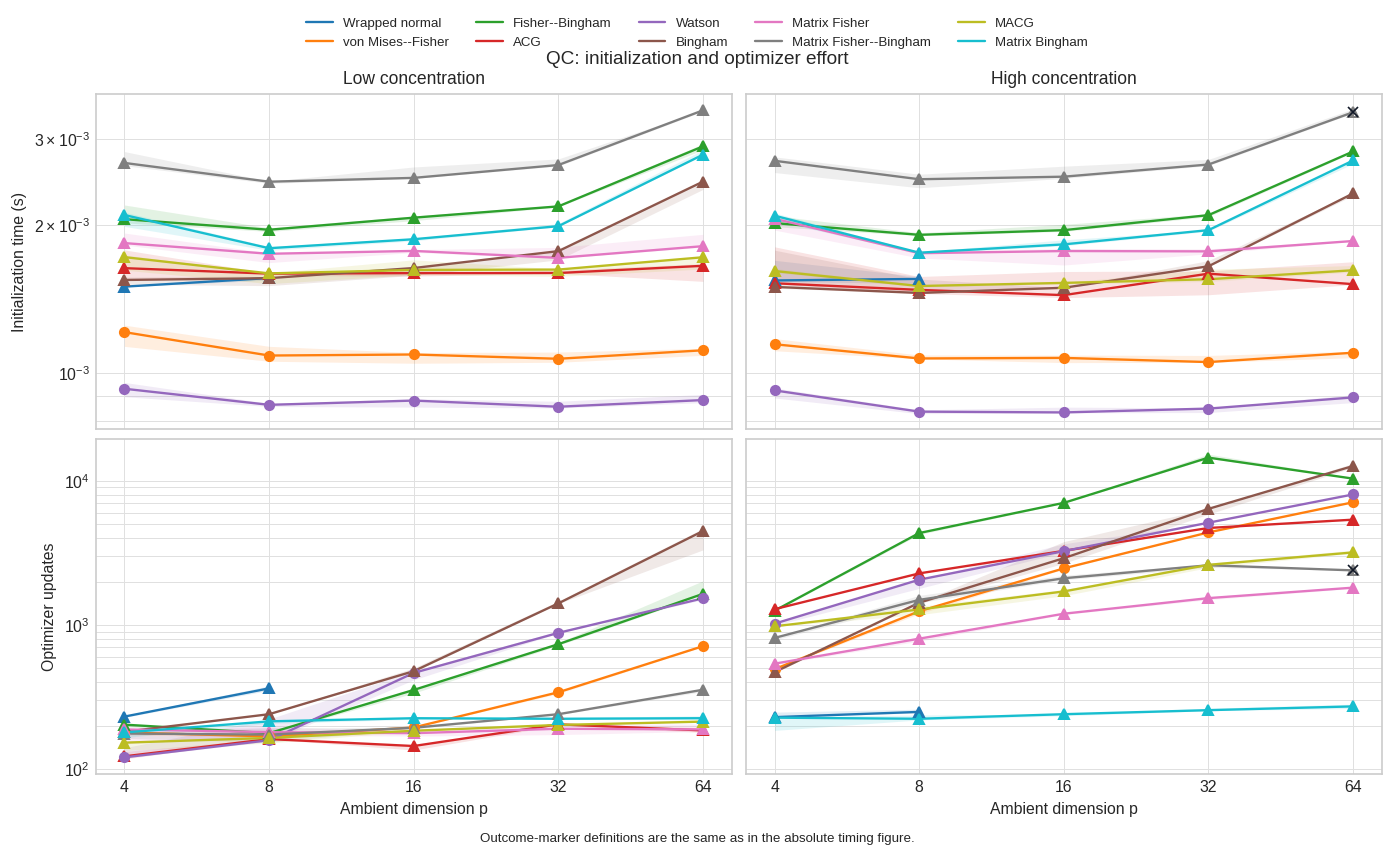

In [29]:
secondary_timing_metrics = [
    ('initialization_seconds', 'Initialization time (s)'),
    ('iterations', 'Optimizer updates'),
]
fig, axes = plt.subplots(
    2, 2, figsize=(11.5, 6.3),
    sharex=True, sharey='row', constrained_layout=True,
)
for row_index, (metric, ylabel) in enumerate(secondary_timing_metrics):
    for column_index, concentration in enumerate(CONCENTRATION_ORDER):
        ax = axes[row_index, column_index]
        add_model_series(ax, cell_summary, metric, concentration)
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xticks(recorded_dimensions)
        ax.set_xticklabels([str(value) for value in recorded_dimensions])
        ax.grid(True, which='both', color='0.88', linewidth=0.6)
        if row_index == 0:
            ax.set_title(f'{concentration.capitalize()} concentration')
        if column_index == 0:
            ax.set_ylabel(ylabel)
        if row_index == 1:
            ax.set_xlabel('Ambient dimension p')
handles, labels = unique_model_legend(axes)
if handles:
    fig.legend(
        handles, labels, ncol=5, loc='upper center',
        bbox_to_anchor=(0.5, 1.08), frameon=False,
    )
fig.suptitle('QC: initialization and optimizer effort', y=1.02)
fig.text(
    0.5, -0.015,
    'Outcome-marker definitions are the same as in the absolute timing figure.',
    ha='center', va='top', fontsize=8,
)
plt.show()


## QC: seed-orientation sensitivity under paired independent starts

Each fit_repeat uses an independent orientation, paired by repeat index across comparable cells, with total identifiable departure norm 10⁻² and fixed factor spectra. The initial training gain over uniform is recorded before optimization. Narrow within-cell dispersion is therefore direct evidence that seed orientation has little practical effect; wide dispersion identifies cells where an unusually favorable or unfavorable start could influence optimizer effort. This is initialization QC only and does not replace the primary timing table.

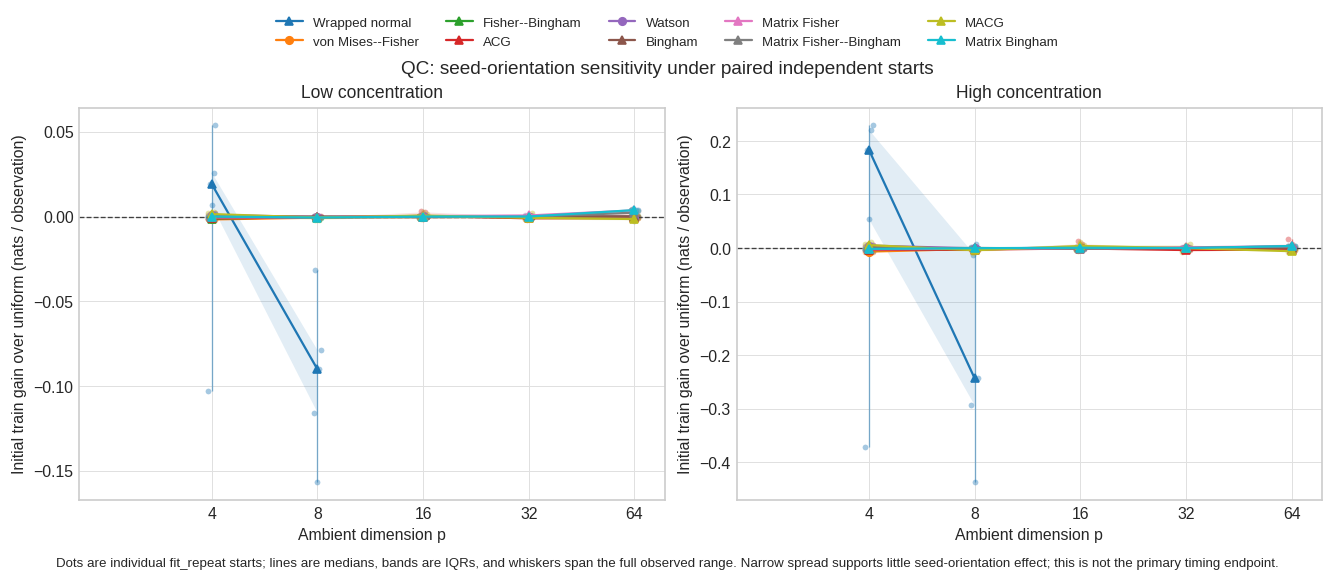

Model,p,Concentration,n,Minimum,Median,Maximum,Range,Maximum − median
Wrapped normal,4,High,5,-0.372,0.184,0.229,0.601,0.0452
Wrapped normal,8,High,5,-0.438,-0.243,0.0065,0.444,0.25
Wrapped normal,4,Low,5,-0.103,0.0193,0.0537,0.157,0.0345
Wrapped normal,8,Low,5,-0.157,-0.09,-0.0315,0.125,0.0586
ACG,64,High,5,-0.0037,-0.00301,0.0177,0.0214,0.0207
ACG,16,High,5,-0.00394,-0.000881,0.0139,0.0179,0.0148
MACG,16,High,5,-0.00638,0.00368,0.0106,0.0169,0.00688
MACG,32,High,5,-0.00681,-0.000302,0.00794,0.0147,0.00824
MACG,8,High,5,-0.00861,-0.00419,0.0024,0.011,0.0066
MACG,4,High,5,0.000887,0.00541,0.0116,0.0107,0.00618


In [30]:
initial_gain_column = 'initial_train_log_score_gain_over_uniform'
initial_rows = latest.loc[
    np.isfinite(pd.to_numeric(latest[initial_gain_column], errors='coerce'))
].copy()
initial_rows[initial_gain_column] = pd.to_numeric(
    initial_rows[initial_gain_column], errors='coerce'
)

if initial_rows.empty:
    display(HTML(
        '<p><em>Independent-start score fields are not available in this '
        'result schema. This QC appears automatically for schema-v3 runs.</em></p>'
    ))
else:
    fig, axes = plt.subplots(
        1, 2, figsize=(11.0, 3.9),
        sharex=True, sharey=False, constrained_layout=True,
    )
    for ax, concentration in zip(axes, CONCENTRATION_ORDER):
        concentration_rows = initial_rows.loc[
            initial_rows['concentration_label'].eq(concentration)
        ]
        for distribution in MODEL_ORDER:
            model_rows = concentration_rows.loc[
                concentration_rows['distribution'].eq(distribution)
            ].copy()
            if model_rows.empty:
                continue
            grouped = (
                model_rows.groupby('ambient_dim')[initial_gain_column]
                .agg(
                    minimum='min',
                    median='median',
                    maximum='max',
                    q1=lambda values: values.quantile(0.25),
                    q3=lambda values: values.quantile(0.75),
                )
                .reset_index()
                .sort_values('ambient_dim')
            )
            x = grouped['ambient_dim'].to_numpy(dtype=float)
            median = grouped['median'].to_numpy(dtype=float)
            color = MODEL_COLORS[distribution]
            marker = RANK_MARKERS.get(
                str(model_rows['rank_label'].iloc[0]), 'o'
            )
            ax.plot(
                x, median, color=color, linewidth=1.35,
                marker=marker, markersize=4.5,
                label=MODEL_INFO[distribution][0], zorder=3,
            )
            ax.fill_between(
                x,
                grouped['q1'].to_numpy(dtype=float),
                grouped['q3'].to_numpy(dtype=float),
                color=color, alpha=0.13, linewidth=0, zorder=1,
            )
            ax.vlines(
                x,
                grouped['minimum'].to_numpy(dtype=float),
                grouped['maximum'].to_numpy(dtype=float),
                color=color, alpha=0.55, linewidth=0.8, zorder=2,
            )
            repeat_offset = (
                pd.to_numeric(model_rows['fit_repeat'], errors='coerce')
                - (requested_repeats - 1) / 2
            )
            jittered_x = (
                model_rows['ambient_dim'].to_numpy(dtype=float)
                * np.power(
                    2.0,
                    repeat_offset.to_numpy(dtype=float) * 0.018,
                )
            )
            ax.scatter(
                jittered_x,
                model_rows[initial_gain_column].to_numpy(dtype=float),
                s=12, color=color, alpha=0.40, linewidths=0, zorder=2,
            )
        ax.axhline(0, color='0.25', linewidth=0.8, linestyle='--')
        ax.set_xscale('log', base=2)
        ax.set_xticks(recorded_dimensions)
        ax.set_xticklabels([str(value) for value in recorded_dimensions])
        ax.set_title(f'{concentration.capitalize()} concentration')
        ax.set_xlabel('Ambient dimension p')
        ax.set_ylabel(
            'Initial train gain over uniform (nats / observation)'
        )
        ax.grid(True, color='0.88', linewidth=0.6)
    handles, labels = unique_model_legend(axes)
    if handles:
        fig.legend(
            handles, labels, ncol=5, loc='upper center',
            bbox_to_anchor=(0.5, 1.16), frameon=False,
        )
    fig.suptitle(
        'QC: seed-orientation sensitivity under paired independent starts',
        y=1.04,
    )
    fig.text(
        0.5, -0.02,
        'Dots are individual fit_repeat starts; lines are medians, bands are '
        'IQRs, and whiskers span the full observed range. Narrow spread supports '
        'little seed-orientation effect; this is not the primary timing endpoint.',
        ha='center', va='top', fontsize=8,
    )
    plt.show()

    initial_dispersion = (
        initial_rows.groupby(
            [
                'distribution', 'ambient_dim',
                'concentration_label',
            ],
            as_index=False,
        )[initial_gain_column]
        .agg(
            repeats='count',
            minimum='min',
            q1=lambda values: values.quantile(0.25),
            median='median',
            q3=lambda values: values.quantile(0.75),
            maximum='max',
        )
    )
    initial_dispersion['range'] = (
        initial_dispersion['maximum'] - initial_dispersion['minimum']
    )
    initial_dispersion['maximum_minus_median'] = (
        initial_dispersion['maximum'] - initial_dispersion['median']
    )
    initial_dispersion['Model'] = initial_dispersion['distribution'].map(
        lambda value: MODEL_INFO.get(value, (value, '', 0))[0]
    )
    widest_starts = (
        initial_dispersion.sort_values(
            ['range', 'maximum_minus_median'],
            ascending=False,
        )
        .head(min(12, len(initial_dispersion)))
        .rename(columns={
            'ambient_dim': 'p',
            'concentration_label': 'Concentration',
            'repeats': 'n',
            'minimum': 'Minimum',
            'median': 'Median',
            'maximum': 'Maximum',
            'range': 'Range',
            'maximum_minus_median': 'Maximum − median',
        })
    )
    widest_starts['Concentration'] = (
        widest_starts['Concentration'].str.capitalize()
    )
    display(
        widest_starts[[
            'Model', 'p', 'Concentration', 'n',
            'Minimum', 'Median', 'Maximum',
            'Range', 'Maximum − median',
        ]]
        .style.hide(axis='index')
        .format({
            'Minimum': '{:.3g}',
            'Median': '{:.3g}',
            'Maximum': '{:.3g}',
            'Range': '{:.3g}',
            'Maximum − median': '{:.3g}',
        })
        .set_caption(
            'Cells with the largest observed seed-orientation dispersion. '
            'The maximum-minus-median column highlights unusually favorable starts.'
        )
    )


## QC: fixed-state objective and normalizer kernels

Schema v3 times repeated scalar value-plus-gradient evaluations at the restored fitted state. The full fixed-objective benchmark includes all density work; the parameter-only normalizer benchmark isolates the recorded normalizer expression. A missing normalizer measurement is shown as N/A, and the curves are descriptive rather than a monotonicity requirement.

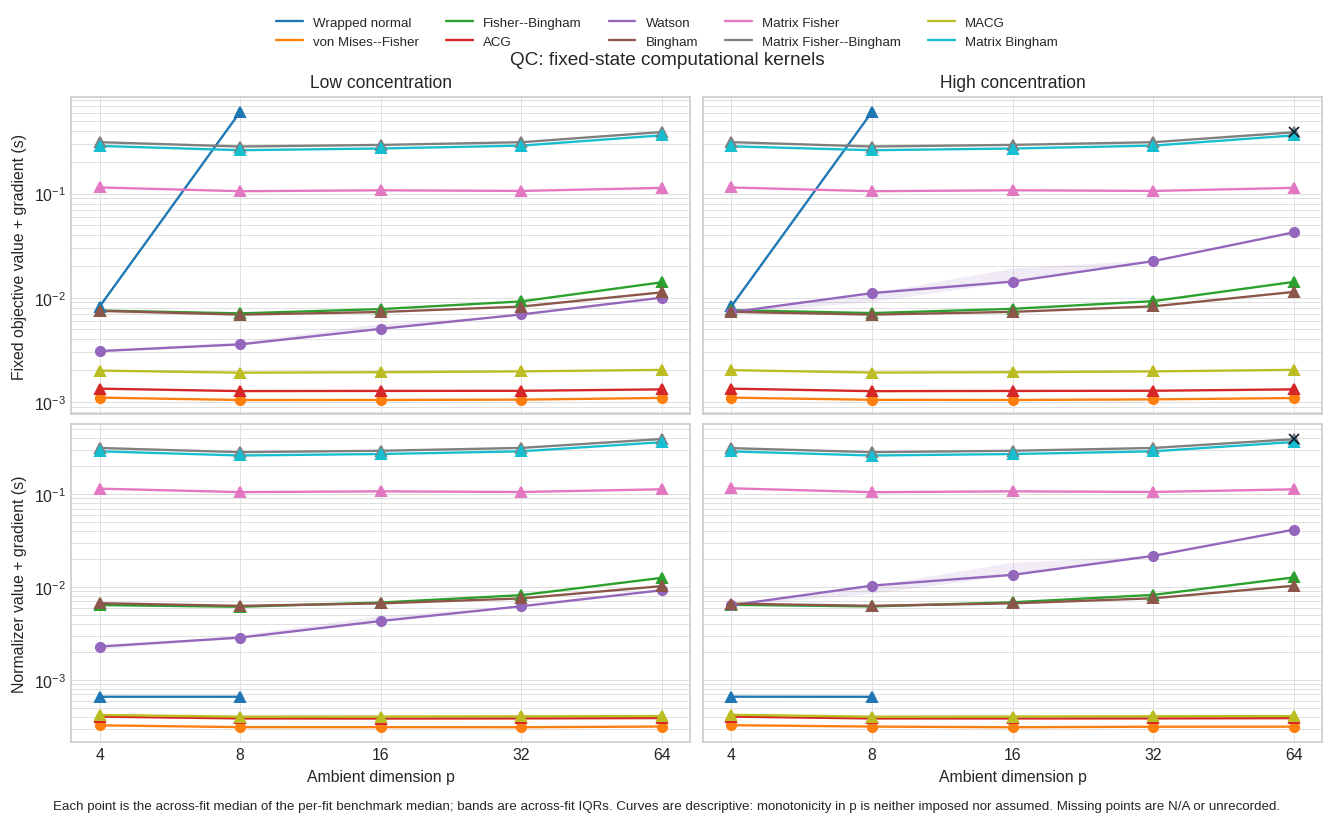

Model,Normalizer benchmark expression,Finite fit-level benchmarks
Wrapped normal,closed_form_gaussian_log_determinant,20
von Mises--Fisher,scaled_modified_bessel_function_cpu,50
Fisher--Bingham,continuous_euler_quadrature,50
ACG,closed_form_log_determinant,50
Watson,kummer_series,50
Bingham,eigendecomposition_plus_continuous_euler_quadrature,50
Matrix Fisher,second_order_saddlepoint_relative_to_normalized_haar,50
Matrix Fisher--Bingham,second_order_saddlepoint_relative_to_normalized_haar,50
MACG,closed_form_log_determinant,50
Matrix Bingham,second_order_saddlepoint_relative_to_normalized_haar,50


In [31]:
kernel_metrics = [
    (
        'fixed_objective_value_gradient_wall_median_seconds',
        'Fixed objective value + gradient (s)',
    ),
    (
        'normalizer_value_gradient_wall_median_seconds',
        'Normalizer value + gradient (s)',
    ),
]
kernel_fields_available = any(
    metric in latest
    and np.isfinite(pd.to_numeric(latest[metric], errors='coerce')).any()
    for metric, _ in kernel_metrics
)

if not kernel_fields_available:
    display(HTML(
        '<p><em>Fixed-state value-and-gradient benchmark fields are not '
        'available in this result schema. They will appear automatically '
        'for schema-v3 results.</em></p>'
    ))
else:
    fig, axes = plt.subplots(
        2, 2, figsize=(11.0, 6.0),
        sharex=True, sharey='row', constrained_layout=True,
    )
    for row_index, (metric, ylabel) in enumerate(kernel_metrics):
        for column_index, concentration in enumerate(CONCENTRATION_ORDER):
            ax = axes[row_index, column_index]
            add_model_series(ax, cell_summary, metric, concentration)
            ax.set_xscale('log', base=2)
            ax.set_yscale('log')
            ax.set_xticks(recorded_dimensions)
            ax.set_xticklabels([str(value) for value in recorded_dimensions])
            ax.grid(True, which='both', color='0.88', linewidth=0.6)
            finite_here = np.isfinite(pd.to_numeric(
                cell_summary.loc[
                    cell_summary['concentration_label'].eq(concentration),
                    f'{metric}_median',
                ],
                errors='coerce',
            )).any()
            if not finite_here:
                ax.text(
                    0.5, 0.5, 'N/A / not recorded',
                    transform=ax.transAxes, ha='center', va='center',
                    color='#6b7280',
                )
            if row_index == 0:
                ax.set_title(f'{concentration.capitalize()} concentration')
            if column_index == 0:
                ax.set_ylabel(ylabel)
            if row_index == 1:
                ax.set_xlabel('Ambient dimension p')
    handles, labels = unique_model_legend(axes)
    if handles:
        fig.legend(
            handles, labels, ncol=5, loc='upper center',
            bbox_to_anchor=(0.5, 1.09), frameon=False,
        )
    fig.suptitle(
        'QC: fixed-state computational kernels',
        y=1.025,
    )
    fig.text(
        0.5, -0.015,
        'Each point is the across-fit median of the per-fit benchmark median; '
        'bands are across-fit IQRs. Curves are descriptive: monotonicity in p '
        'is neither imposed nor assumed. Missing points are N/A or unrecorded.',
        ha='center', va='top', fontsize=8,
    )
    plt.show()

    kind_records = []
    for distribution in MODEL_ORDER:
        subset = latest.loc[
            latest['distribution'].eq(distribution)
            & np.isfinite(pd.to_numeric(
                latest['normalizer_value_gradient_wall_median_seconds'],
                errors='coerce',
            ))
        ]
        kinds = sorted(
            value
            for value in subset.get(
                'normalizer_benchmark_kind', pd.Series(dtype=str)
            ).dropna().astype(str).str.strip().unique()
            if value
        )
        kind_records.append({
            'Model': MODEL_INFO[distribution][0],
            'Normalizer benchmark expression': (
                '; '.join(kinds) if kinds else 'N/A / not recorded'
            ),
            'Finite fit-level benchmarks': int(len(subset)),
        })
    display(
        pd.DataFrame(kind_records)
        .style.hide(axis='index')
        .set_caption(
            'Parameter-only normalizer expression timed in the fixed-state QC. '
            'This may differ from the full density normalizer label.'
        )
    )


## QC: high-to-low concentration ratios

Each ratio is formed within the same fit-repeat index before taking the median and IQR. This avoids replacing the distribution of paired ratios with a ratio of two marginal medians.

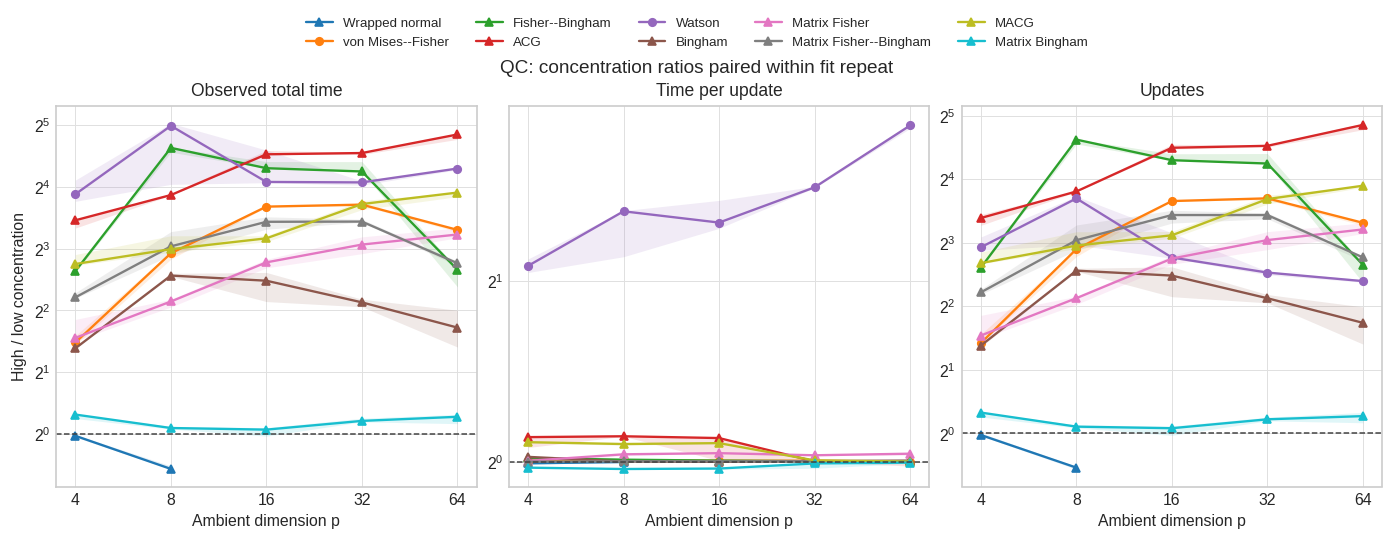

In [32]:
pair_keys = [
    'distribution', 'ambient_dim', 'matrix_cols',
    'rank_label', 'fit_repeat',
]
ratio_metrics = [
    ('observed_fit_seconds', 'Observed total time'),
    ('median_seconds_per_iteration', 'Time per update'),
    ('iterations', 'Updates'),
]
timed_latest = latest.loc[latest['timed_flag']].copy()
ratio_records = []
for metric, title in ratio_metrics:
    if metric not in timed_latest:
        continue
    paired = timed_latest.pivot_table(
        index=pair_keys,
        columns='concentration_label',
        values=metric,
        aggfunc='last',
    )
    if not {'low', 'high'}.issubset(paired.columns):
        continue
    paired = paired[['low', 'high']].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    paired = paired.loc[
        paired['low'].gt(0) & paired['high'].gt(0)
    ].copy()
    paired['ratio'] = paired['high'] / paired['low']
    paired = paired.reset_index()
    for keys, group in paired.groupby(
        ['distribution', 'ambient_dim', 'matrix_cols', 'rank_label'],
        sort=False,
    ):
        q1, median, q3 = group['ratio'].quantile([0.25, 0.5, 0.75])
        ratio_records.append({
            'metric': metric,
            'metric_title': title,
            'distribution': keys[0],
            'ambient_dim': int(keys[1]),
            'matrix_cols': int(keys[2]),
            'rank_label': keys[3],
            'ratio_q1': float(q1),
            'ratio_median': float(median),
            'ratio_q3': float(q3),
            'paired_repeats': int(len(group)),
        })
ratio_summary = pd.DataFrame(ratio_records)

fig, axes = plt.subplots(
    1, 3, figsize=(11.5, 3.8),
    sharex=True, constrained_layout=True,
)
for ax, (metric, title) in zip(axes, ratio_metrics):
    metric_data = ratio_summary.loc[
        ratio_summary['metric'].eq(metric)
    ] if len(ratio_summary) else pd.DataFrame()
    for distribution in MODEL_ORDER:
        series = metric_data.loc[
            metric_data['distribution'].eq(distribution)
        ].sort_values('ambient_dim') if len(metric_data) else pd.DataFrame()
        if series.empty:
            continue
        color = MODEL_COLORS[distribution]
        x = series['ambient_dim'].to_numpy(dtype=float)
        y = series['ratio_median'].to_numpy(dtype=float)
        q1 = series['ratio_q1'].to_numpy(dtype=float)
        q3 = series['ratio_q3'].to_numpy(dtype=float)
        ax.plot(
            x, y, marker=RANK_MARKERS.get(
                str(series['rank_label'].iloc[0]), 'o'
            ),
            linewidth=1.4, markersize=4.5, color=color,
            label=MODEL_INFO[distribution][0],
        )
        ax.fill_between(
            x, q1, q3, color=color, alpha=0.13, linewidth=0,
        )
    ax.axhline(1, color='0.25', linewidth=0.9, linestyle='--')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.set_xticks(recorded_dimensions)
    ax.set_xticklabels([str(value) for value in recorded_dimensions])
    ax.set_title(title)
    ax.set_xlabel('Ambient dimension p')
    ax.grid(True, which='both', color='0.88', linewidth=0.6)
axes[0].set_ylabel('High / low concentration')
handles, labels = unique_model_legend(axes)
if handles:
    fig.legend(
        handles, labels, ncol=5, loc='upper center',
        bbox_to_anchor=(0.5, 1.16), frameon=False,
    )
fig.suptitle(
    'QC: concentration ratios paired within fit repeat',
    y=1.04,
)
plt.show()

if len(ratio_summary):
    incomplete_pairs = ratio_summary.loc[
        ratio_summary['paired_repeats'].lt(requested_repeats),
        [
            'metric_title', 'distribution', 'ambient_dim',
            'paired_repeats',
        ],
    ]
    if len(incomplete_pairs):
        display(
            incomplete_pairs.style.hide(axis='index')
            .set_caption('Ratio cells with fewer than the requested paired repeats')
        )


## QC: held-out gain over uniform

This is an accuracy guardrail, not the timing endpoint. Finite scores from limit-stopped attempts remain visible and carry the same outcome markers as the timing plots.

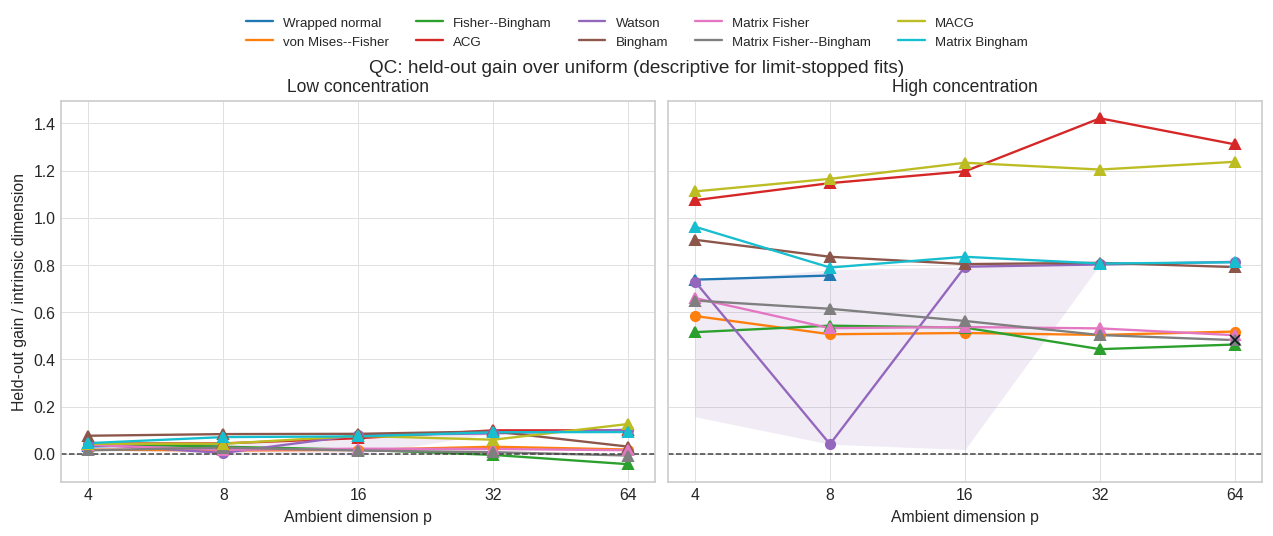

In [33]:
fig, axes = plt.subplots(
    1, 2, figsize=(10.5, 3.8),
    sharex=True, sharey=True, constrained_layout=True,
)
for ax, concentration in zip(axes, CONCENTRATION_ORDER):
    add_model_series(
        ax,
        cell_summary,
        'heldout_log_score_gain_per_dof',
        concentration,
        require_positive=False,
    )
    ax.axhline(0, color='0.25', linewidth=0.9, linestyle='--')
    ax.set_xscale('log', base=2)
    ax.set_xticks(recorded_dimensions)
    ax.set_xticklabels([str(value) for value in recorded_dimensions])
    ax.set_title(f'{concentration.capitalize()} concentration')
    ax.set_xlabel('Ambient dimension p')
    ax.grid(True, color='0.88', linewidth=0.6)
axes[0].set_ylabel('Held-out gain / intrinsic dimension')
handles, labels = unique_model_legend(axes)
if handles:
    fig.legend(
        handles, labels, ncol=5, loc='upper center',
        bbox_to_anchor=(0.5, 1.15), frameon=False,
    )
fig.suptitle(
    'QC: held-out gain over uniform (descriptive for limit-stopped fits)',
    y=1.03,
)
plt.show()


## QC: matrix normalizer-order sensitivity

The comparison is second-order minus first-order mean held-out log likelihood at the parameters fitted with the primary configured normalizer (second order in schema v3). It measures sensitivity to approximation order; it is not a separate refit and is excluded from primary timing.

In [34]:
delta_column = 'order2_minus_order1_heldout_log_likelihood'
if delta_column in latest:
    validation = latest.loc[
        np.isfinite(pd.to_numeric(latest[delta_column], errors='coerce')),
        [
            'distribution', 'ambient_dim', 'concentration_label',
            delta_column, 'converged_flag',
            'iteration_limit_flag', 'time_limit_flag',
        ] + (
            ['second_order_validation_seconds']
            if 'second_order_validation_seconds' in latest else []
        ),
    ].copy()
    validation[delta_column] = pd.to_numeric(
        validation[delta_column], errors='coerce'
    )
    if 'second_order_validation_seconds' not in validation:
        validation['second_order_validation_seconds'] = np.nan
    validation['second_order_validation_seconds'] = pd.to_numeric(
        validation['second_order_validation_seconds'], errors='coerce'
    )

    validation_errors = 0
    if 'second_order_validation_error' in latest:
        validation_errors = int(
            latest['second_order_validation_error']
            .fillna('').astype(str).str.strip().ne('').sum()
        )

    if validation.empty:
        display(HTML(
            '<p><em>No finite normalizer-order comparison has been recorded yet.</em></p>'
        ))
    else:
        validation_summary = (
            validation.groupby(
                ['distribution', 'ambient_dim', 'concentration_label'],
                as_index=False,
            )
            .agg(
                repeats=(delta_column, 'count'),
                converged=('converged_flag', 'sum'),
                limit_stopped=(
                    'iteration_limit_flag',
                    lambda values: int(values.sum()),
                ),
                delta_median=(delta_column, 'median'),
                delta_q1=(
                    delta_column,
                    lambda values: values.quantile(0.25),
                ),
                delta_q3=(
                    delta_column,
                    lambda values: values.quantile(0.75),
                ),
                validation_seconds=(
                    'second_order_validation_seconds', 'median'
                ),
            )
        )
        validation_summary['Model'] = validation_summary[
            'distribution'
        ].map(lambda value: MODEL_INFO.get(value, (value, '', 0))[0])
        validation_summary['p'] = validation_summary[
            'ambient_dim'
        ].astype(int)
        validation_summary['Concentration'] = validation_summary[
            'concentration_label'
        ].str.capitalize()
        validation_summary['Difference'] = validation_summary.apply(
            lambda row: (
                f"{row['delta_median']:.3g} "
                f"[{row['delta_q1']:.3g}, {row['delta_q3']:.3g}] "
                f"(n={int(row['repeats'])}, "
                f"{int(row['converged'])}/{int(row['repeats'])} converged)"
            ),
            axis=1,
        )
        validation_table = validation_summary.pivot(
            index=['Model', 'p'],
            columns='Concentration',
            values='Difference',
        )
        overhead = validation[
            'second_order_validation_seconds'
        ].median()
        overhead_text = (
            f'{overhead:.3g} s' if pd.notna(overhead) else 'unavailable'
        )
        display(validation_table.style.set_caption(
            'Second-order minus first-order mean held-out log likelihood, '
            'median [IQR], evaluated at the first-order fitted parameters. '
            f'Median validation overhead: {overhead_text}; '
            f'validation errors: {validation_errors}.'
        ))


## Publication table: mean total fitting time

Low and high concentration are combined in one table. Each cell is the arithmetic mean across normally terminated repeats. If every timed repeat terminated prematurely, the mean across those attempts is retained as a lower bound and prefixed with `>`. Every cell uses the same logarithmic color scale, and the table and colorbar are exported together as a publication-ready PNG.

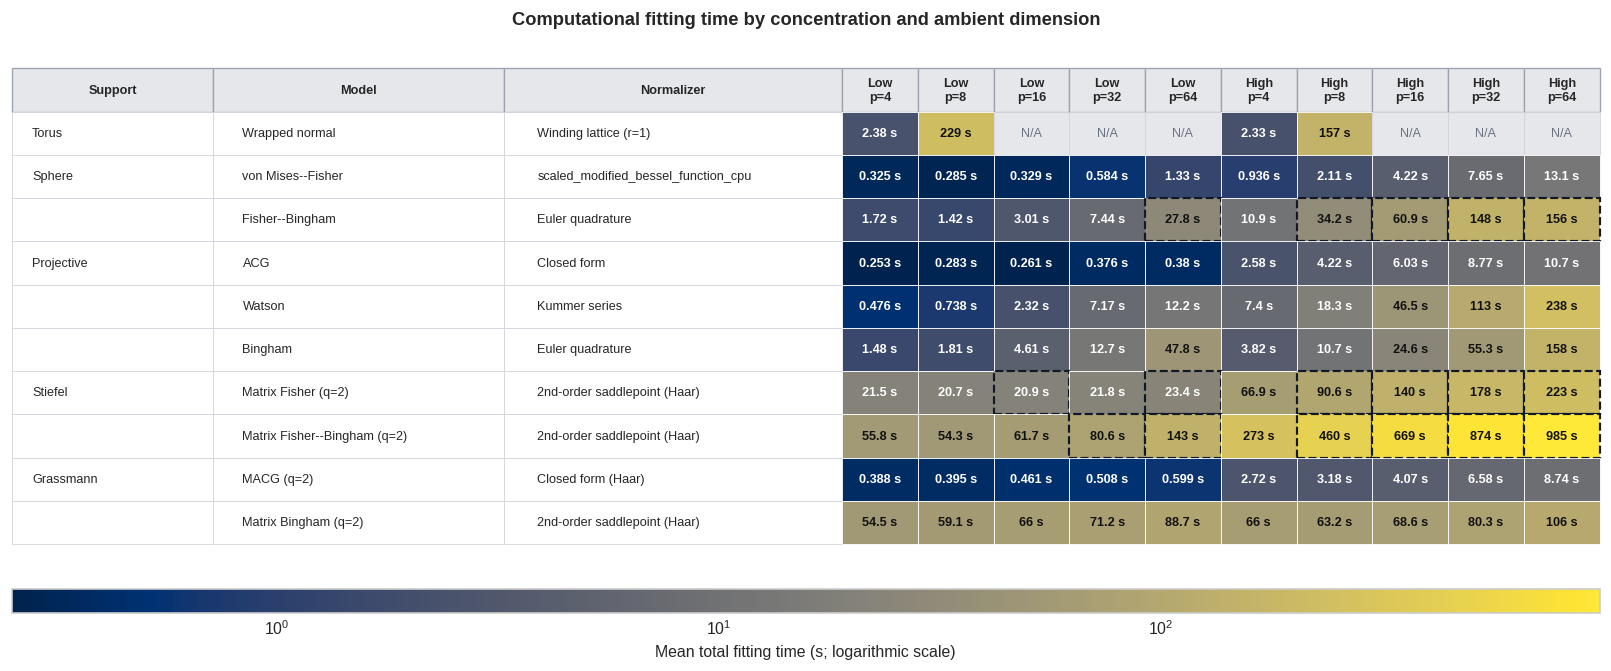

In [35]:
def format_seconds(value) -> str:
    if pd.isna(value):
        return ''
    return f'{float(value):.3g} s'

# Rank is omitted when it is fixed by model; if a future run has multiple ranks,
# append it to the model label so rows remain unique.
rank_counts = cell_summary.groupby('table_model')['rank_label'].nunique()
cell_summary['publication_model'] = cell_summary.apply(
    lambda row: (
        f"{row['table_model']}, {row['rank']}"
        if rank_counts.get(row['table_model'], 1) > 1
        else row['table_model']
    ),
    axis=1,
)
row_columns = ['manifold', 'publication_model', 'normalizer']
row_order = (
    cell_summary.sort_values(
        ['_manifold_order', 'model_order', '_rank_order']
    )[row_columns].drop_duplicates()
)
row_index = pd.MultiIndex.from_frame(
    row_order, names=['Support', 'Model', 'Normalizer']
)

publication_dimensions = sorted(
    cell_summary.loc[
        cell_summary['recorded_repeats'].gt(0), 'ambient_dim'
    ].dropna().astype(int).unique()
)
if not publication_dimensions:
    publication_dimensions = sorted(
        cell_summary['ambient_dim'].dropna().astype(int).unique()
    )

completed_means = pd.to_numeric(
    cell_summary['converged_observed_fit_seconds_mean'], errors='coerce'
)
all_attempt_means = pd.to_numeric(
    cell_summary['observed_fit_seconds_mean'], errors='coerce'
)
has_completed_fit = cell_summary[
    'converged_observed_fit_seconds_n'
].gt(0) & np.isfinite(completed_means)
cell_summary['publication_time_seconds'] = completed_means.where(
    has_completed_fit, all_attempt_means
)
cell_summary['publication_time_lower_bound'] = (
    ~has_completed_fit
    & cell_summary['timed_attempts'].gt(0)
    & np.isfinite(all_attempt_means)
)
finite_publication_times = pd.to_numeric(
    cell_summary['publication_time_seconds'], errors='coerce'
)
finite_publication_times = finite_publication_times[
    np.isfinite(finite_publication_times) & finite_publication_times.gt(0)
]
if len(finite_publication_times):
    color_min = float(finite_publication_times.min())
    color_max = float(finite_publication_times.max())
    if math.isclose(color_min, color_max):
        color_max = color_min * 1.01
    publication_norm = LogNorm(vmin=color_min, vmax=color_max)
else:
    publication_norm = None
publication_cmap = plt.get_cmap('cividis')

concentration_names = {'low': 'Low', 'high': 'High'}

def make_publication_table():
    columns = pd.MultiIndex.from_product(
        [
            [concentration_names[value] for value in CONCENTRATION_ORDER],
            publication_dimensions,
        ],
        names=['Concentration', 'Ambient dimension p'],
    )
    display_values = pd.DataFrame('—', index=row_index, columns=columns)
    color_values = pd.DataFrame(
        np.nan, index=row_index, columns=columns, dtype=float
    )
    code_values = pd.DataFrame(
        'not planned', index=row_index, columns=columns
    )

    for _, row in cell_summary.iterrows():
        p = int(row['ambient_dim'])
        concentration = concentration_names.get(
            str(row['concentration_label']).lower()
        )
        column_key = (concentration, p)
        if concentration is None or column_key not in columns:
            continue
        row_key = tuple(row[column] for column in row_columns)
        n_timed = int(row['timed_attempts'])
        publication_time = row['publication_time_seconds']
        lower_bound = bool(row['publication_time_lower_bound'])
        if n_timed > 0 and pd.notna(publication_time):
            prefix = '>' if lower_bound else ''
            display_values.at[row_key, column_key] = (
                prefix + format_seconds(publication_time)
            )
            color_values.at[row_key, column_key] = float(publication_time)
            qualifications = []
            if lower_bound:
                qualifications.append('lower bound')
            if int(row['iteration_limit_fits']) or int(row['time_limit_fits']):
                qualifications.append('limit')
            if int(row['error_fits']):
                qualifications.append('error')
            if int(row['pending_repeats']):
                qualifications.append('pending')
            if bool(row['sampling_qc_warning']):
                qualifications.append('sampling warning')
            code_values.at[row_key, column_key] = (
                ' '.join(qualifications) if qualifications else 'timed'
            )
        elif int(row['skipped_fits']):
            display_values.at[row_key, column_key] = 'N/A'
            code_values.at[row_key, column_key] = 'no result'
        elif int(row['error_fits']):
            display_values.at[row_key, column_key] = 'ERR'
            code_values.at[row_key, column_key] = 'no result'
        elif int(row['pending_repeats']):
            display_values.at[row_key, column_key] = '…'
            code_values.at[row_key, column_key] = 'pending'

    def style_row(row_values: pd.Series):
        styles = []
        for column in row_values.index:
            value = color_values.at[row_values.name, column]
            code = code_values.at[row_values.name, column]
            if pd.notna(value) and publication_norm is not None:
                rgba = publication_cmap(publication_norm(float(value)))
                background = mcolors.to_hex(rgba)
                luminance = (
                    0.2126 * rgba[0] + 0.7152 * rgba[1]
                    + 0.0722 * rgba[2]
                )
                foreground = (
                    '#111111' if luminance > 0.52 else '#ffffff'
                )
                border = (
                    '2px dashed #111827'
                    if code != 'timed'
                    else '1px solid #ffffff'
                )
                styles.append(
                    f'background-color:{background};color:{foreground};'
                    f'font-weight:600;border:{border}'
                )
            elif code == 'pending':
                styles.append(
                    'background-color:#f9fafb;color:#6b7280;'
                    'font-style:italic'
                )
            elif code == 'not planned':
                styles.append(
                    'background-color:#ffffff;color:#9ca3af'
                )
            else:
                styles.append(
                    'background-color:#e5e7eb;color:#4b5563;'
                    'font-style:italic'
                )
        return styles

    caption = 'Mean total fitting time by concentration and dimension'
    table_styles = [
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('font-family', 'sans-serif'),
                ('font-size', '8.5pt'),
                ('width', '100%'),
            ],
        },
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-weight', '700'),
                ('text-align', 'left'),
                ('font-size', '10pt'),
                ('padding-bottom', '0.55em'),
            ],
        },
        {
            'selector': 'thead th',
            'props': [
                ('background-color', '#f3f4f6'),
                ('border-bottom', '1px solid #9ca3af'),
                ('padding', '5px 6px'),
                ('text-align', 'center'),
            ],
        },
        {
            'selector': 'tbody th',
            'props': [
                ('padding', '5px 7px'),
                ('text-align', 'left'),
                ('border-bottom', '1px solid #e5e7eb'),
                ('white-space', 'pre-line'),
            ],
        },
        {
            'selector': 'tbody td',
            'props': [
                ('padding', '6px 7px'),
                ('text-align', 'center'),
                ('white-space', 'pre-line'),
                ('min-width', '82px'),
            ],
        },
        {
            'selector': '.row_heading.level0',
            'props': [
                ('font-weight', '700'),
                ('border-top', '2px solid #6b7280'),
            ],
        },
    ]
    styled = (
        display_values.style
        .apply(style_row, axis=1)
        .set_caption(caption)
        .set_table_styles(table_styles)
        .set_uuid('computational-fit-time')
    )
    return display_values, color_values, code_values, styled

publication_table = make_publication_table()

if benchmark_is_draft:
    display(HTML(
        '<div style="border:2px solid #b45309;background:#fff7ed;color:#7c2d12;'
        'padding:0.7em 0.9em;margin:0.7em 0;font-family:sans-serif">'
        f'<strong>DRAFT — {unresolved_attempts} planned attempts remain unresolved.</strong> '
        'The table shows every finite timing currently recorded.'
        '</div>'
    ))

display(HTML(
    '<div style="font-family:sans-serif;font-size:9pt;margin:0.4em 0">'
    '<strong>Cell notation.</strong> Values are means across normally '
    'terminated repeats. A leading &gt; marks the mean observed stopping '
    'time when every timed repeat terminated prematurely, hence a lower '
    'bound on completion time. A dashed border marks any qualification; '
    'N/A, ERR, and … denote unavailable, failed, and pending cells.'
    '</div>'
))

display(publication_table[3])

def export_publication_table_png(
    display_values: pd.DataFrame,
    color_values: pd.DataFrame,
    code_values: pd.DataFrame,
    output_path: Path,
) -> Path:
    timing_columns = list(display_values.columns)
    column_labels = ['Support', 'Model', 'Normalizer'] + [
        f'{concentration}\np={dimension}'
        for concentration, dimension in timing_columns
    ]
    cell_text = []
    previous_support = None
    for row_key, values in display_values.iterrows():
        support, model, normalizer = row_key
        support_label = '' if support == previous_support else support
        previous_support = support
        cell_text.append(
            [support_label, model, normalizer, *values.astype(str).tolist()]
        )

    n_timing_columns = max(len(timing_columns), 1)
    descriptor_widths = [0.125, 0.18, 0.21]
    timing_width = (0.985 - sum(descriptor_widths)) / n_timing_columns
    column_widths = descriptor_widths + [timing_width] * n_timing_columns
    figure_width = max(13.5, 5.8 + 0.75 * n_timing_columns)
    figure_height = max(5.4, 1.3 + 0.43 * len(cell_text))
    figure = plt.figure(figsize=(figure_width, figure_height))
    grid = figure.add_gridspec(
        2, 1, height_ratios=[max(len(cell_text), 1) + 1, 0.55],
        left=0.01, right=0.99, top=0.91, bottom=0.10, hspace=0.18,
    )
    table_axis = figure.add_subplot(grid[0])
    color_axis = figure.add_subplot(grid[1])
    table_axis.axis('off')
    table = table_axis.table(
        cellText=cell_text,
        colLabels=column_labels,
        colWidths=column_widths,
        cellLoc='center',
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7.6)

    for column_index in range(len(column_labels)):
        header = table[(0, column_index)]
        header.set_facecolor('#e5e7eb')
        header.set_edgecolor('#9ca3af')
        header.set_linewidth(0.8)
        header.get_text().set_weight('bold')

    for row_index in range(len(cell_text)):
        for descriptor_index in range(3):
            descriptor = table[(row_index + 1, descriptor_index)]
            descriptor.set_facecolor('#ffffff')
            descriptor.set_edgecolor('#d1d5db')
            descriptor.set_linewidth(0.5)
            descriptor.get_text().set_ha('left')
        for timing_index in range(len(timing_columns)):
            table_cell = table[(row_index + 1, timing_index + 3)]
            value = color_values.iloc[row_index, timing_index]
            code = str(code_values.iloc[row_index, timing_index])
            if pd.notna(value) and publication_norm is not None:
                rgba = publication_cmap(publication_norm(float(value)))
                table_cell.set_facecolor(rgba)
                luminance = (
                    0.2126 * rgba[0] + 0.7152 * rgba[1]
                    + 0.0722 * rgba[2]
                )
                table_cell.get_text().set_color(
                    '#111111' if luminance > 0.52 else '#ffffff'
                )
                table_cell.get_text().set_weight('bold')
                qualified = code != 'timed'
                table_cell.set_edgecolor(
                    '#111827' if qualified else '#ffffff'
                )
                table_cell.set_linewidth(1.3 if qualified else 0.5)
                table_cell.set_linestyle('--' if qualified else '-')
            else:
                table_cell.set_facecolor(
                    '#f9fafb' if code in {'pending', 'not planned'} else '#e5e7eb'
                )
                table_cell.set_edgecolor('#d1d5db')
                table_cell.set_linewidth(0.5)
                table_cell.get_text().set_color('#6b7280')

    colorbar = figure.colorbar(
        ScalarMappable(norm=publication_norm, cmap=publication_cmap),
        cax=color_axis,
        orientation='horizontal',
    )
    colorbar.set_label('Mean total fitting time (s; logarithmic scale)')
    figure.suptitle(
        'Computational fitting time by concentration and ambient dimension',
        fontsize=11, fontweight='bold', y=0.995,
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        output_path, dpi=300, bbox_inches='tight', facecolor='white'
    )
    plt.show()
    return output_path

publication_png_path = results_path.parent / 'computational_fit_time_table.png'
if publication_norm is not None:
    export_publication_table_png(
        publication_table[0], publication_table[1], publication_table[2],
        publication_png_path,
    )
    display(HTML(
        f'<p><strong>PNG written to:</strong> {publication_png_path}</p>'
    ))

publication_html = publication_table[3].to_html()
publication_latex = publication_table[0].to_latex(
        escape=True,
        caption='Mean total fitting time by concentration and dimension.',
        label='tab:computational-fit-time',
    )


## Fitting time by ambient dimension


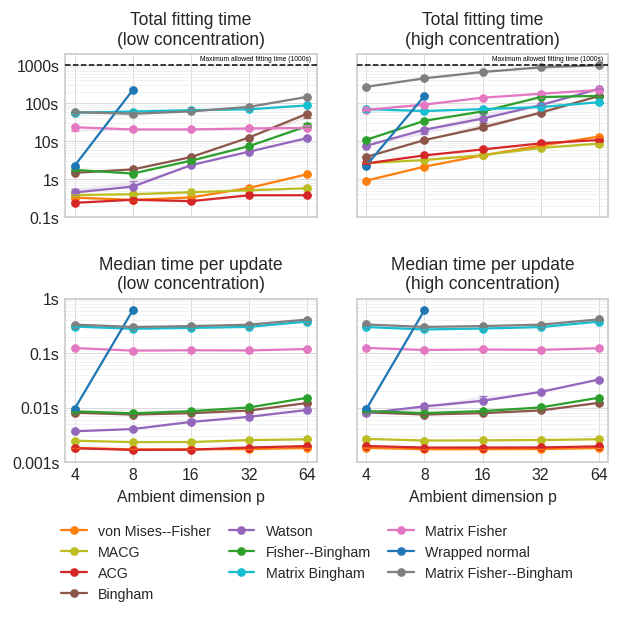

In [36]:
def add_publication_timing_series(
    ax,
    data: pd.DataFrame,
    metric: str,
    concentration: str,
    model_order: list[str],
):
    subset = data.loc[data['concentration_label'].eq(concentration)]
    for distribution in model_order:
        series = subset.loc[
            subset['distribution'].eq(distribution)
        ].sort_values('ambient_dim')
        if series.empty:
            continue
        x = series['ambient_dim'].to_numpy(dtype=float)
        y = series[f'{metric}_median'].to_numpy(dtype=float)
        q1 = series[f'{metric}_q1'].to_numpy(dtype=float)
        q3 = series[f'{metric}_q3'].to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y) & (y > 0)
        if not valid.any():
            continue
        color = MODEL_COLORS[distribution]
        line_y = np.where(valid, y, np.nan)
        ax.plot(
            x, line_y, color=color, linewidth=1.35,
            marker='o', markersize=4.2,
            markerfacecolor=color, markeredgecolor=color,
            zorder=3,
        )
        band = valid & np.isfinite(q1) & np.isfinite(q3) & (q1 > 0)
        if band.any():
            ax.fill_between(
                x[band], q1[band], q3[band],
                color=color, alpha=0.13, linewidth=0, zorder=2,
            )
            lower_error = y[band] - q1[band]
            upper_error = q3[band] - y[band]
            nonnegative_error = (lower_error >= 0) & (upper_error >= 0)
            if nonnegative_error.any():
                ax.errorbar(
                    x[band][nonnegative_error],
                    y[band][nonnegative_error],
                    yerr=np.vstack([
                        lower_error[nonnegative_error],
                        upper_error[nonnegative_error],
                    ]),
                    fmt='none', ecolor=color, elinewidth=0.8,
                    capsize=2.2, capthick=0.8, alpha=0.85, zorder=4,
                )


# Order models by median total fitting time for high concentration at p=8.
legend_reference = cell_summary.loc[
    cell_summary['concentration_label'].eq('high')
    & cell_summary['ambient_dim'].eq(8)
].copy()
legend_reference['_legend_time'] = pd.to_numeric(
    legend_reference['observed_fit_seconds_median'], errors='coerce'
)
legend_reference = (
    legend_reference.loc[
        np.isfinite(legend_reference['_legend_time'])
        & legend_reference['_legend_time'].gt(0)
    ]
    .groupby('distribution')['_legend_time']
    .median()
)
model_position = {name: index for index, name in enumerate(MODEL_ORDER)}
timing_legend_order = sorted(
    MODEL_ORDER,
    key=lambda name: (
        name not in legend_reference.index,
        float(legend_reference.get(name, np.inf)),
        model_position[name],
    ),
)

publication_timing_metrics = [
    (
        'observed_fit_seconds',
        'Total fitting time',
        (0.1, 2000),
        [0.1, 1, 10, 100, 1000],
    ),
    (
        'median_seconds_per_iteration',
        'Median time per update',
        (0.001, 1),
        [0.001, 0.01, 0.1, 1],
    ),
]

fig, axes = plt.subplots(
    2, 2, figsize=(5, 4), sharex=True, sharey='row',
)
for row_index, (metric, panel_name, limits, ticks) in enumerate(
    publication_timing_metrics
):
    for column_index, concentration in enumerate(CONCENTRATION_ORDER):
        ax = axes[row_index, column_index]
        add_publication_timing_series(
            ax, cell_summary, metric, concentration, timing_legend_order
        )
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xlim(min(recorded_dimensions) / 1.12, max(recorded_dimensions) * 1.12)
        ax.set_ylim(*limits)
        ax.set_xticks(recorded_dimensions)
        ax.set_xticklabels([str(value) for value in recorded_dimensions])
        ax.set_yticks(ticks)
        ax.set_yticklabels([f'{value:g}s' for value in ticks])
        ax.grid(True, which='major', color='0.86', linewidth=0.6)
        ax.grid(True, which='minor', color='0.93', linewidth=0.45)
        ax.set_title(
            f'{panel_name}\n({concentration} concentration)', pad=6
        )
        if row_index == 1:
            ax.set_xlabel('Ambient dimension p')
        if row_index == 0:
            ax.axhline(
                1000, color='black', linestyle='--', linewidth=0.9,
                zorder=4,
            )
            ax.text(
                0.98, 1200, 'Maximum allowed fitting time (1000s)',
                transform=ax.get_yaxis_transform(), ha='right', va='bottom',
                fontsize=4, color='black',
            )

legend_handles = [
    Line2D(
        [0], [0], color=MODEL_COLORS[distribution], linewidth=1.35,
        marker='o', markersize=4.2,
        markerfacecolor=MODEL_COLORS[distribution],
        markeredgecolor=MODEL_COLORS[distribution],
        label=MODEL_INFO[distribution][0],
    )
    for distribution in timing_legend_order
]
if legend_handles:
    fig.legend(
        handles=legend_handles,
        ncol=3,
        loc='center', bbox_to_anchor=(0.5, -0.1),
        frameon=False, columnspacing=1.25, handlelength=1.8,
        fontsize=8.5
    )

fig.subplots_adjust(
    left=0.08, right=0.985, top=0.96, bottom=0.11,
    hspace=0.5, wspace=0.16,
)
publication_timing_png_path = (
    results_path.parent / 'computational_fitting_times.png'
)
figure_output_is_current = not benchmark_is_draft
if figure_output_is_current:
    fig.savefig(
        publication_timing_png_path,
        dpi=300, bbox_inches='tight', facecolor='white',
    )
plt.show()
if figure_output_is_current:
    display(HTML(
        f'<p><strong>PNG written to:</strong> '
        f'{publication_timing_png_path}</p>'
    ))


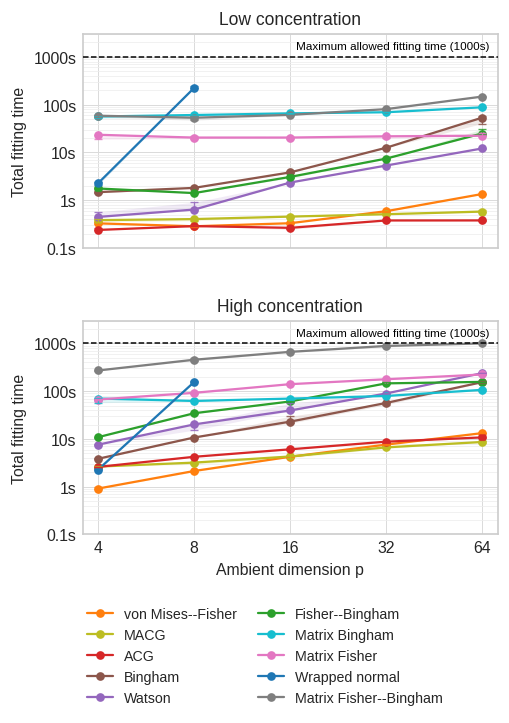

In [37]:
total_time_limits = (0.1, 3000)
total_time_ticks = [0.1, 1, 10, 100, 1000]

fig, axes = plt.subplots(
    2, 1, figsize=(4, 6), sharex=True, sharey=True,
)
for ax, concentration in zip(axes, CONCENTRATION_ORDER):
    add_publication_timing_series(
        ax, cell_summary, 'observed_fit_seconds', concentration,
        timing_legend_order,
    )
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlim(
        min(recorded_dimensions) / 1.12,
        max(recorded_dimensions) * 1.12,
    )
    ax.set_ylim(*total_time_limits)
    ax.set_xticks(recorded_dimensions)
    ax.set_xticklabels([str(value) for value in recorded_dimensions])
    ax.set_yticks(total_time_ticks)
    ax.set_yticklabels([f'{value:g}s' for value in total_time_ticks])
    ax.grid(True, which='major', color='0.86', linewidth=0.6)
    ax.grid(True, which='minor', color='0.93', linewidth=0.45)
    ax.set_title(f'{concentration.capitalize()} concentration', pad=6)
    ax.set_ylabel('Total fitting time')
    ax.axhline(
        1000, color='black', linestyle='--', linewidth=0.9, zorder=4,
    )
    ax.text(
        0.98, 1300, 'Maximum allowed fitting time (1000s)',
        transform=ax.get_yaxis_transform(), ha='right', va='bottom',
        fontsize=7, color='black',
    )
axes[-1].set_xlabel('Ambient dimension p')

total_time_legend_handles = [
    Line2D(
        [0], [0], color=MODEL_COLORS[distribution], linewidth=1.35,
        marker='o', markersize=4.2,
        markerfacecolor=MODEL_COLORS[distribution],
        markeredgecolor=MODEL_COLORS[distribution],
        label=MODEL_INFO[distribution][0],
    )
    for distribution in timing_legend_order
]
if total_time_legend_handles:
    fig.legend(
        handles=total_time_legend_handles, ncol=2, loc='lower center',
        bbox_to_anchor=(0.5, 0.015), frameon=False,
        columnspacing=1.5, handlelength=1.8, fontsize=8.5,
    )

fig.subplots_adjust(
    left=0.12, right=0.985, top=0.965, bottom=0.27, hspace=0.34,
)
total_fitting_time_png_path = (
    results_path.parent / 'computational_total_fitting_time.png'
)
if figure_output_is_current:
    fig.savefig(
        total_fitting_time_png_path,
        dpi=300, bbox_inches='tight', facecolor='white',
    )
plt.show()
if figure_output_is_current:
    display(HTML(
        f'<p><strong>PNG written to:</strong> '
        f'{total_fitting_time_png_path}</p>'
    ))


## Alternative: show both concentrations together

These are two compact layout examples using the same all-attempt medians and IQRs as the main timing plots. Each panel is one method; concentration is encoded by fill or line style, so the model color stays consistent.

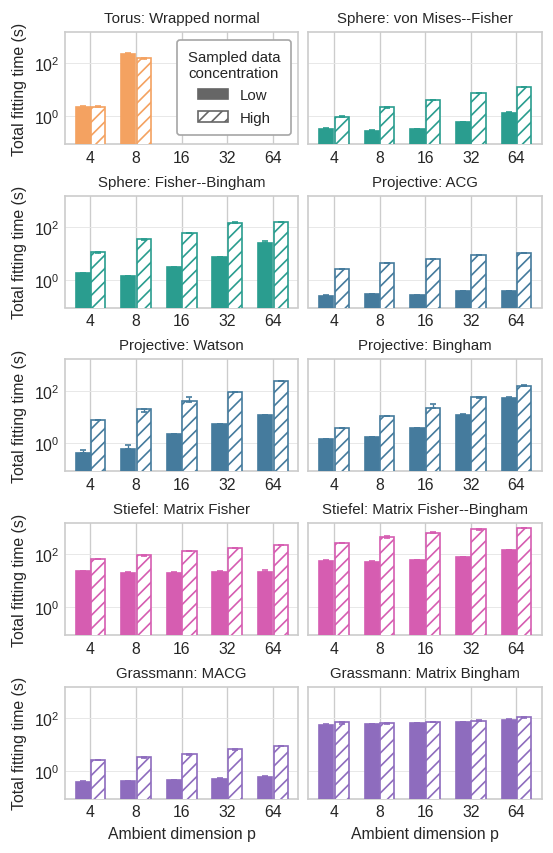

In [41]:
# Example 1: paired bars at each dimension, grouped by manifold (5 x 2).
# Low is filled; high uses the same manifold color with a hatched, white fill.
# Colors follow the task-state benchmark palette, assigned consistently by support.
MANIFOLD_COLORS = {
    'Torus': '#F4A261',
    'Sphere': '#2A9D8F',
    'Projective': '#457B9D',
    'Stiefel': '#D65DB1',
    'Grassmann': '#8E6CBE',
}
observed_distributions = set(cell_summary['distribution'])
bar_models = [
    name for manifold in MANIFOLD_ORDER for name in MODEL_ORDER
    if MODEL_INFO[name][1] == manifold and name in observed_distributions
]
bar_dimensions = list(recorded_dimensions)
fig, axes = plt.subplots(5, 2, figsize=(4.5, 7), sharex=True, sharey=True, constrained_layout=True)
bar_width = 0.34
for ax, distribution in zip(axes.flat, bar_models):
    model_data = cell_summary.loc[cell_summary['distribution'].eq(distribution)]
    manifold = MODEL_INFO[distribution][1]
    color = MANIFOLD_COLORS[manifold]
    for concentration, offset, filled in [('low', -bar_width / 2, True), ('high', bar_width / 2, False)]:
        series = model_data.loc[model_data['concentration_label'].eq(concentration)].set_index('ambient_dim').reindex(bar_dimensions)
        med = pd.to_numeric(series['observed_fit_seconds_median'], errors='coerce').to_numpy(dtype=float)
        q1 = pd.to_numeric(series['observed_fit_seconds_q1'], errors='coerce').to_numpy(dtype=float)
        q3 = pd.to_numeric(series['observed_fit_seconds_q3'], errors='coerce').to_numpy(dtype=float)
        x = np.arange(len(bar_dimensions), dtype=float) + offset
        bars = ax.bar(x, med, width=bar_width * 0.92, color=color if filled else 'white',
                      edgecolor=color, linewidth=1.0, hatch=None if filled else '///', zorder=3)
        valid = np.isfinite(med) & np.isfinite(q1) & np.isfinite(q3) & (med > 0) & (q1 > 0)
        if valid.any():
            ax.errorbar(x[valid], med[valid], yerr=np.vstack([med[valid] - q1[valid], q3[valid] - med[valid]]),
                        fmt='none', ecolor=color, elinewidth=0.8, capsize=2, zorder=4)
    ax.set_title(f"{manifold}: {MODEL_INFO[distribution][0]}", fontsize=9)
    ax.set_yscale('log')
    ax.grid(True, axis='y', which='both', color='0.9', linewidth=0.55, zorder=0)
for ax in axes.flat:
    ax.set_xticks(np.arange(len(bar_dimensions)))
    ax.set_xticklabels([str(p) for p in bar_dimensions])
    ax.tick_params(axis='x', labelbottom=True)
for ax in axes[-1, :]:
    ax.set_xlabel('Ambient dimension p')
for ax in axes[:, 0]:
    ax.set_ylabel('Total fitting time (s)')
axes[0, 0].legend(handles=[
    plt.Rectangle((0, 0), 1, 1, facecolor='#666666', edgecolor='#666666', label='Low'),
    plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='#666666', hatch='///', label='High'),
], loc='upper right', title='Sampled data\nconcentration', fontsize=9, title_fontsize=9,
   frameon=True, facecolor='white', framealpha=1.0, edgecolor='0.65',
   borderpad=0.7, labelspacing=0.55)
# fig.suptitle('Total fitting time by method, dimension, and concentration', y=1.01)
plt.savefig(results_path.parent / 'computational_fitting_time_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
